1.Extract data

Considering the computer performance and memory, the data from April 1, 2013 to January 1, 2023 will be extracted in three stages using keywords to extract the 'the complaint' and 'what happened' columns

In [ ]:
!pip install pdfplumber
!pip install PyMuPDF
!pip install ace_tools
!pip install transformers

In [ ]:
!pip install pandas nltk spacy
!python -m spacy download en_core_web_sm


In [ ]:

%run scrape.py get-metadata --industry-sector "insurance" --from 2020-01-01 --to 2023-01-01 
%run scrape.py download-decisions

In [ ]:
import os
print("Current working directory:", os.getcwd())


In [ ]:
import pandas as pd
import fitz  # PyMuPDF
import os

def extract_complaint_decision_and_happened_from_pdf(pdf_path):
    try:
        # open PDF
        doc = fitz.open(pdf_path)
        complaint_text = ""
        decision_text = ""
        happened_text = ""
        full_text = ""
        
        # Traverse each page and concatenate all the text
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            full_text += page.get_text()
        
        # Extract the content of the 'the complaint' section
        if "the complaint" in full_text.lower():
            start_idx = full_text.lower().find("the complaint")
            end_idx = full_text.lower().find("what happened", start_idx)
            if end_idx == -1:
                complaint_text = full_text[start_idx:].strip()
            else:
                complaint_text = full_text[start_idx:end_idx].strip()
            complaint_text = complaint_text.replace("The complaint", "").strip()
            complaint_text = complaint_text.replace("the complaint", "").strip()

        # Extract the content from the 'my final decision' section
        if "my final decision" in full_text.lower():
            start_idx = full_text.lower().find("my final decision")
            decision_text = full_text[start_idx:].strip()
            decision_text = decision_text.replace("My final decision", "").strip()
            decision_text = decision_text.replace("my final decision", "").strip()
        
        # Extract the content from the 'what happened' section
        if "what happened" in full_text.lower():
            start_idx = full_text.lower().find("what happened")
            end_idx = full_text.lower().find("what i’ve decided", start_idx)
            if end_idx == -1:
                happened_text = full_text[start_idx:].strip()
            else:
                happened_text = full_text[start_idx:end_idx].strip()
            happened_text = happened_text.replace("What happened", "").strip()
            happened_text = happened_text.replace("what happened", "").strip()
        
        # remove line breaks
        complaint_text = " ".join(complaint_text.split())
        decision_text = " ".join(decision_text.split())
        happened_text = " ".join(happened_text.split())

        return complaint_text, decision_text, happened_text
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")
        return "", "", ""

# read metadata.csv
metadata_df = pd.read_csv('metadata.csv')

# Add new column
metadata_df['the complaint'] = ""
metadata_df['final decision'] = ""
metadata_df['what happened'] = ""

# Loop each line and extract the corresponding "the complaint", "final decision", and "what happened" contents of the PDF file
for index, row in metadata_df.iterrows():
    pdf_relative_path = row['location']
    # Ensure that the path correctly points to the decisions folder
    pdf_path = os.path.join('decisions', os.path.basename(pdf_relative_path))
    if os.path.exists(pdf_path):
        complaint_text, decision_text, happened_text = extract_complaint_decision_and_happened_from_pdf(pdf_path)
        metadata_df.at[index, 'the complaint'] = complaint_text
        metadata_df.at[index, 'final decision'] = decision_text
        metadata_df.at[index, 'what happened'] = happened_text
    else:
        print(f"File not found: {pdf_path}")

# save date from2020-2023
metadata_df.to_csv('2020-2023updated_metadata.csv', index=False)


#print(metadata_df.head())




In [ ]:

%run scrape.py get-metadata --industry-sector "insurance" --from 2016-01-01 --to 2019-12-31 

%run scrape.py download-decisions

The steps for processing data from 2016 to 2019 are very similar

In [ ]:
import pandas as pd
import fitz  # PyMuPDF
import os

def extract_complaint_decision_and_happened_from_pdf(pdf_path):
    try:
        # open PDF
        doc = fitz.open(pdf_path)
        complaint_text = ""
        decision_text = ""
        happened_text = ""
        full_text = ""
        
        # Traverse each page and concatenate all the text
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            full_text += page.get_text()
        
        # extract "the complaint" 
        if "the complaint" in full_text.lower():
            start_idx = full_text.lower().find("the complaint")
            end_idx = full_text.lower().find("what happened", start_idx)
            if end_idx == -1:
                complaint_text = full_text[start_idx:].strip()
            else:
                complaint_text = full_text[start_idx:end_idx].strip()
            complaint_text = complaint_text.replace("The complaint", "").strip()
            complaint_text = complaint_text.replace("the complaint", "").strip()

        #  extract "my final decision" 
        if "my final decision" in full_text.lower():
            start_idx = full_text.lower().find("my final decision")
            decision_text = full_text[start_idx:].strip()
            decision_text = decision_text.replace("My final decision", "").strip()
            decision_text = decision_text.replace("my final decision", "").strip()
        
        #  extract "what happened" 
        if "what happened" in full_text.lower():
            start_idx = full_text.lower().find("what happened")
            end_idx = full_text.lower().find("what i’ve decided", start_idx)
            if end_idx == -1:
                happened_text = full_text[start_idx:].strip()
            else:
                happened_text = full_text[start_idx:end_idx].strip()
            happened_text = happened_text.replace("What happened", "").strip()
            happened_text = happened_text.replace("what happened", "").strip()
        
        # Remove line breaks
        complaint_text = " ".join(complaint_text.split())
        decision_text = " ".join(decision_text.split())
        happened_text = " ".join(happened_text.split())

        return complaint_text, decision_text, happened_text
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")
        return "", "", ""

# read metadata.csv
metadata_df = pd.read_csv('metadata.csv')

# add column
metadata_df['the complaint'] = ""
metadata_df['final decision'] = ""
metadata_df['what happened'] = ""

# Traverse each line and extract the corresponding "the complaint", "final decision", and "what happened" contents of the PDF file
for index, row in metadata_df.iterrows():
    pdf_relative_path = row['location']
    # Ensure that the path correctly points to the decisions folder
    pdf_path = os.path.join('decisions', os.path.basename(pdf_relative_path))
    if os.path.exists(pdf_path):
        complaint_text, decision_text, happened_text = extract_complaint_decision_and_happened_from_pdf(pdf_path)
        metadata_df.at[index, 'the complaint'] = complaint_text
        metadata_df.at[index, 'final decision'] = decision_text
        metadata_df.at[index, 'what happened'] = happened_text
    else:
        print(f"File not found: {pdf_path}")

# updated the data of 2016-2019 
metadata_df.to_csv('2016-2019updated_metadata.csv', index=False)

# print(metadata_df.head())

In [ ]:

%run scrape.py get-metadata --industry-sector "insurance" --from 2013-04-01 --to 2015-12-31 
%run scrape.py download-decisions

In [ ]:
import pandas as pd
import fitz  # PyMuPDF
import os

def extract_complaint_decision_and_happened_from_pdf(pdf_path):
    try:
        # read PDF
        doc = fitz.open(pdf_path)
        complaint_text = ""
        decision_text = ""
        happened_text = ""
        full_text = ""
        
        # Traverse each page and concatenate all the text
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            full_text += page.get_text()
        
        lower_text = full_text.lower()

        # extract "the complaint" and "what happened" 
        if "the complaint" in lower_text:
            start_idx = lower_text.find("the complaint")
            end_idx = lower_text.find("what happened", start_idx)
            if end_idx == -1:
                complaint_text = full_text[start_idx:].strip()
                happened_text = ""  # if  'what happened' section is missing
            else:
                complaint_text = full_text[start_idx:end_idx].strip()
                # find "what happened"
                start_happened = lower_text.find("what happened", end_idx)
                end_happened = lower_text.find("what i’ve decided", start_happened)
                if end_happened == -1:
                    happened_text = full_text[start_happened:].strip()
                else:
                    happened_text = full_text[start_happened:end_happened].strip()

            # remove title
            complaint_text = complaint_text.replace("The complaint", "").strip()
            complaint_text = complaint_text.replace("the complaint", "").strip()
            happened_text = happened_text.replace("What happened", "").strip()
            happened_text = happened_text.replace("what happened", "").strip()

        # If 'the complaint' is not found, search for 'complaint' and 'background'
        elif "complaint" in lower_text:
            start_idx = lower_text.find("complaint")
            end_idx = lower_text.find("background", start_idx)
            if end_idx == -1:
                complaint_text = full_text[start_idx:].strip()
                happened_text = ""  # "background" is missing
            else:
                complaint_text = full_text[start_idx:end_idx].strip()
                # search for "background"
                start_background = lower_text.find("background", end_idx)
                end_background = lower_text.find("my findings", start_background)
                if end_background == -1:
                    happened_text = full_text[start_background:].strip()
                else:
                    happened_text = full_text[start_background:end_background].strip()

            # remove title
            complaint_text = complaint_text.replace("Complaint", "").strip()
            complaint_text = complaint_text.replace("complaint", "").strip()
            happened_text = happened_text.replace("Background", "").strip()
            happened_text = happened_text.replace("background", "").strip()
        
        # extract "my final decision" 
        if "my final decision" in lower_text:
            start_idx = lower_text.find("my final decision")
            decision_text = full_text[start_idx:].strip()
            decision_text = decision_text.replace("My final decision", "").strip()
            decision_text = decision_text.replace("my final decision", "").strip()
        
        # remove line break
        complaint_text = " ".join(complaint_text.split())
        decision_text = " ".join(decision_text.split())
        happened_text = " ".join(happened_text.split())

        return complaint_text, decision_text, happened_text
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")
        return "", "", ""

# read metadata.csv 
metadata_df = pd.read_csv('metadata.csv')

# add new columns
metadata_df['the complaint'] = ""
metadata_df['final decision'] = ""
metadata_df['what happened'] = ""

# Traverse each line and extract the corresponding "the complaint", "final decision", and "what happened" contents of the PDF file
for index, row in metadata_df.iterrows():
    pdf_relative_path = row['location']
   
    pdf_path = os.path.join('decisions', os.path.basename(pdf_relative_path))
    if os.path.exists(pdf_path):
        complaint_text, decision_text, happened_text = extract_complaint_decision_and_happened_from_pdf(pdf_path)
        metadata_df.at[index, 'the complaint'] = complaint_text
        metadata_df.at[index, 'final decision'] = decision_text
        metadata_df.at[index, 'what happened'] = happened_text
    else:
        print(f"File not found: {pdf_path}")

# save data from 2013-2015
metadata_df.to_csv('2013-2015updated_metadata.csv', index=False)

# print(metadata_df.head())


In [164]:
import pandas as pd

# read CSV 
df1= pd.read_csv('2013-2015updated_metadata.csv')
df2 = pd.read_csv('2016-2019updated_metadata.csv')
df3 = pd.read_csv('2020-2023updated_metadata.csv')

combined_df = pd.concat([df1, df2,df3])
# combine DataFrame

metadata_df = combined_df
# Save the merged DataFrame as a new CSV file
metadata_df.to_csv('new.csv', index=False)

In [165]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61705 entries, 0 to 22249
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   decision_id     61705 non-null  object 
 1   location        61705 non-null  object 
 2   title           61705 non-null  object 
 3   date            61705 non-null  object 
 4   company         61705 non-null  object 
 5   decision        61705 non-null  object 
 6   extras          0 non-null      float64
 7   tag             61705 non-null  object 
 8   the complaint   50713 non-null  object 
 9   final decision  61465 non-null  object 
 10  what happened   25838 non-null  object 
dtypes: float64(1), object(10)
memory usage: 5.6+ MB


Search again for the missing part regarding what happened and the complaint.


Because the complaint formats have been very different in the past decade, there will be many blank spaces in the 2013-2016 period due to the extraction of unified keywords in the early stage. Therefore, it is necessary to extract the 'the complaint' and 'what happened' multiple times until the content positions that meet the requirements can no longer be extracted

In [166]:

import pandas as pd
import pdfplumber  
import os
import numpy as np  
import pandas as pd
import pdfplumber
import os
import numpy as np

def extract_complaint_and_happened_from_pdf(pdf_path):
    try:
        complaint_text = ""
        happened_text = ""
        
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            for page in pdf.pages:
                full_text += page.extract_text() or ""

        lower_text = full_text.lower()

        start_complaint_idx = lower_text.find("complaint") + len("complaint")
        end_complaint_idx = lower_text.find("background", start_complaint_idx)
        if start_complaint_idx != -1 and end_complaint_idx != -1:
            complaint_text = full_text[start_complaint_idx:end_complaint_idx]
            complaint_text = " ".join(complaint_text.split()).strip()

        start_background_idx = lower_text.find("background") + len("background")
        end_background_idx = lower_text.find("my findings", start_background_idx)
        if start_background_idx != -1 and end_background_idx != -1:
            happened_text = full_text[start_background_idx:end_background_idx]
            happened_text = " ".join(happened_text.split()).strip()

        return complaint_text, happened_text
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")
        return "", ""

# load metadata.csv
metadata_df = pd.read_csv('new.csv')

for index, row in metadata_df.iterrows():
    # Check if 'what happened' or 'the complaint' is NaN
    if pd.isna(row['what happened']) or pd.isna(row['the complaint']):
        decision_id = row['decision_id']
        pdf_path = f"decisions\\{decision_id}.pdf"
        if os.path.exists(pdf_path):
            complaint_text, happened_text = extract_complaint_and_happened_from_pdf(pdf_path)
            # Update 'the complaint' and 'what happened', even if one already has content
            metadata_df.at[index, 'the complaint'] = complaint_text
            metadata_df.at[index, 'what happened'] = happened_text
        else:
            print(f"File not found: {pdf_path}")

#print(metadata_df.head())




In [167]:
import pandas as pd

# check 'what happened' 
what_happened_null_count = metadata_df['what happened'].isnull().sum()
what_happened_empty_count = (metadata_df['what happened'] == '').sum()

print(f"'what happened' column: {what_happened_null_count} null values, {what_happened_empty_count} empty strings")

# check 'the complaint' 
the_complaint_null_count = metadata_df['the complaint'].isnull().sum()
the_complaint_empty_count = (metadata_df['the complaint'] == '').sum()

print(f"'the complaint' column: {the_complaint_null_count} null values, {the_complaint_empty_count} empty strings")
# check 'what happened' 
what_happened_total_rows = metadata_df.shape[0]

print(f"'what happened' column: {what_happened_total_rows} total rows (including null and empty strings)")


'what happened' column: 0 null values, 1640 empty strings
'the complaint' column: 0 null values, 1606 empty strings
'what happened' column: 61705 total rows (including null and empty strings)


In [168]:
def clean_extracted_text(text):
    # Remove unnecessary prefix tags
    text = text.replace('complaint\n', '').replace('initial conclusions\n', '')
    return text.strip()

def extract_complaint_and_happened_cleaned(pdf_path):
    try:
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            for page in pdf.pages:
                full_text += page.extract_text() or ""
        
        # Extract the complaint section and clean it up
        start_complaint_idx = full_text.find("complaint")
        end_complaint_idx = full_text.find("our initial conclusions", start_complaint_idx)
        complaint_text = full_text[start_complaint_idx:end_complaint_idx].strip() if start_complaint_idx != -1 and end_complaint_idx != -1 else ""

        # Extract the updated 'what happened' section and clean it up
        start_happened_idx = full_text.find("initial conclusions")
        end_happened_idx = full_text.find("my final decision", start_happened_idx)
        happened_text = full_text[start_happened_idx:end_happened_idx].strip() if start_happened_idx != -1 and end_happened_idx != -1 else ""

        # Apply cleaning function
        complaint_text = clean_extracted_text(complaint_text)
        happened_text = clean_extracted_text(happened_text)

        return complaint_text, happened_text
    except Exception as e:
        print(f"Error processing {pdf_path}: {e}")
        return "", ""

# Apply the function to a line where 'the_completion' or 'what_cappened' is empty or NaN
for idx, row in metadata_df.iterrows():
    # set pdf location
    pdf_path = f'decisions/{row["decision_id"]}.pdf'
    if pd.isna(row['the complaint']) or row['the complaint'] == "" or pd.isna(row['what happened']) or row['what happened'] == "":
        complaint, happened = extract_complaint_and_happened_cleaned(pdf_path)
        metadata_df.at[idx, 'the complaint'] = complaint if complaint else metadata_df.at[idx, 'the complaint']
        metadata_df.at[idx, 'what happened'] = happened if happened else metadata_df.at[idx, 'what happened']





In [169]:
import pandas as pd
import numpy as np

metadata_df.dropna(subset=['the complaint', 'what happened'], inplace=True)  
metadata_df = metadata_df[(metadata_df['the complaint'] != '') & (metadata_df['what happened'] != '')]

print(metadata_df)


      decision_id                 location                          title  \
0      DRN7002699  decision/DRN7002699.pdf  Decision Reference DRN7002699   
1      DRN3591746  decision/DRN3591746.pdf  Decision Reference DRN3591746   
2      DRN2069766  decision/DRN2069766.pdf  Decision Reference DRN2069766   
3      DRN1913472  decision/DRN1913472.pdf  Decision Reference DRN1913472   
4      DRN9832615  decision/DRN9832615.pdf  Decision Reference DRN9832615   
...           ...                      ...                            ...   
61700  DRN9017557  decision/DRN9017557.pdf  Decision Reference DRN9017557   
61701  DRN9761562  decision/DRN9761562.pdf  Decision Reference DRN9761562   
61702  DRN1350971  decision/DRN1350971.pdf  Decision Reference DRN1350971   
61703  DRN2230781  decision/DRN2230781.pdf  Decision Reference DRN2230781   
61704  DRN5557003  decision/DRN5557003.pdf  Decision Reference DRN5557003   

              date                              company    decision  extras

In [170]:
metadata_df.to_csv('new2.csv', index=False)

In [171]:
metadata_df.info()#for check

<class 'pandas.core.frame.DataFrame'>
Index: 61131 entries, 0 to 61704
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   decision_id     61131 non-null  object 
 1   location        61131 non-null  object 
 2   title           61131 non-null  object 
 3   date            61131 non-null  object 
 4   company         61131 non-null  object 
 5   decision        61131 non-null  object 
 6   extras          0 non-null      float64
 7   tag             61131 non-null  object 
 8   the complaint   61131 non-null  object 
 9   final decision  60921 non-null  object 
 10  what happened   61131 non-null  object 
dtypes: float64(1), object(10)
memory usage: 5.6+ MB


In [174]:
#make sure the data is concerning insurance
metadata_data = metadata_data = metadata_df.loc[metadata_df['tag'].isin(['Insurance', 'Insurance (excluding PPI)'])]
# check
metadata_df.info()#for check


<class 'pandas.core.frame.DataFrame'>
Index: 61131 entries, 0 to 61704
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   decision_id     61131 non-null  object 
 1   location        61131 non-null  object 
 2   title           61131 non-null  object 
 3   date            61131 non-null  object 
 4   company         61131 non-null  object 
 5   decision        61131 non-null  object 
 6   extras          0 non-null      float64
 7   tag             61131 non-null  object 
 8   the complaint   61131 non-null  object 
 9   final decision  60921 non-null  object 
 10  what happened   61131 non-null  object 
dtypes: float64(1), object(10)
memory usage: 5.6+ MB


1.1 data cleaning

In [175]:
import re
# Adjusted cleaning function to also remove single capital letters likely representing surnames
def adjust_clean_text(text):
    # Remove single capital letters that could represent surnames
    text = re.sub(r'\b[A-Z]\b', '', text)
    # Remove potential company names by deleting any word that starts with a capital letter followed by lowercase letters
    text = re.sub(r'\b[A-Z][a-z]+\b', '', text)
    # Remove dates (e.g., 28 May 2024)
    text = re.sub(r'\b\d{1,2}\s+[A-Z][a-z]+\s+\d{4}\b', '', text)
    # Add a space between numbers and words to prevent them from merging
    text = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', text)
    text = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', text)
    # Remove any extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Reapply cleaning function to the 'the complaint' column
metadata_df['adjusted_cleaned_complaint'] = metadata_df['the complaint'].apply(adjust_clean_text)
metadata_df['adjusted_cleaned_whathappened'] = metadata_df['what happened'].apply(adjust_clean_text)
# Display the first few adjusted cleaned texts to verify further cleaning
metadata_df[['the complaint',  'adjusted_cleaned_complaint','adjusted_cleaned_whathappened']].head()


,the complaint,adjusted_cleaned_complaint,adjusted_cleaned_whathappened
0,Miss S complains that HSBC Bank plc sold her L...,complains that HSBC plc sold her LifeChoices p...,2007 took out a personal loan with HSBC. aroun...
1,Mr H’s is unhappy that Royal & Sun Alliance In...,’s is unhappy that & (RSA) – his motor insurer...,left his car in a pub car park and when he cam...
2,Mr W has complained about Amtrust Europe Limit...,has complained about . isn’t happy that it tur...,made a claim under his mobile phone insurance ...
3,Mr and Mrs S complain that Allianz Insurance P...,and complain that refused a claim on a pet ins...,bought a pet insurance policy with online on a...
4,Ms B has complained about how alternative acco...,has complained about how alternative accommoda...,made her claim after her home was flooded in 2...


In [176]:
 
# #Define function to remove company name from text
def remove_company_name(text, company):
        # remove company name
        company_name = re.escape(company)  
        text = re.sub(r'\b' + company_name + r'\b', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    

#Create a new column 'remove_company' and remove the company name
metadata_df['remove_company'] = metadata_df.apply(lambda row: remove_company_name(row['adjusted_cleaned_complaint'], row['company']), axis=1)
metadata_df['whathappenedremove_company'] = metadata_df.apply(lambda row: remove_company_name(row['adjusted_cleaned_whathappened'], row['company']), axis=1)
    
## Define a function to remove parentheses and their contents,
# the symbol '&', and words containing two or more uppercase letters
def remove_unwanted_elements(text):
    # Remove parentheses and their contents
    text = re.sub(r'\([^)]*\)', '', text)
    # Remove"&"
    text = re.sub(r'&', '', text)
    # Remove words containing two or more uppercase letters
    text = ' '.join([word for word in text.split() if not re.search(r'[A-Z].*[A-Z]', word)])
    # Remove extra space
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Apply function
metadata_df['remove_company'] = metadata_df['remove_company'].apply(remove_unwanted_elements)
metadata_df['whathappenedremove_company'] =metadata_df['whathappenedremove_company'].apply(remove_unwanted_elements)
# Display the first few rows to verify the cleaning process
metadata_df[['adjusted_cleaned_complaint', 'remove_company', 'adjusted_cleaned_whathappened', 'whathappenedremove_company']].head()

,adjusted_cleaned_complaint,remove_company,adjusted_cleaned_whathappened,whathappenedremove_company
0,complains that HSBC plc sold her LifeChoices p...,complains that plc sold her protection policie...,2007 took out a personal loan with HSBC. aroun...,2007 took out a personal loan with around the ...
1,’s is unhappy that & (RSA) – his motor insurer...,’s is unhappy that – his motor insurer - didn’...,left his car in a pub car park and when he cam...,left his car in a pub car park and when he cam...
2,has complained about . isn’t happy that it tur...,has complained about . isn’t happy that it tur...,made a claim under his mobile phone insurance ...,made a claim under his mobile phone insurance ...
3,and complain that refused a claim on a pet ins...,and complain that refused a claim on a pet ins...,bought a pet insurance policy with online on a...,bought a pet insurance policy with online on a...
4,has complained about how alternative accommoda...,has complained about how alternative accommoda...,made her claim after her home was flooded in 2...,made her claim after her home was flooded in 2...


In [177]:
#Remove non empty and blank lines
metadata_df = metadata_df[
    (metadata_df['adjusted_cleaned_complaint'] != '') & 
    (metadata_df['remove_company'] != '')
]


In [178]:
# remove the column of final decisions,as it seems to have duplicated the role of decision 
metadata_df = metadata_df.drop('final decision', axis=1)

In [179]:
metadata_df.info()#for check

<class 'pandas.core.frame.DataFrame'>
Index: 61127 entries, 0 to 61704
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   decision_id                    61127 non-null  object 
 1   location                       61127 non-null  object 
 2   title                          61127 non-null  object 
 3   date                           61127 non-null  object 
 4   company                        61127 non-null  object 
 5   decision                       61127 non-null  object 
 6   extras                         0 non-null      float64
 7   tag                            61127 non-null  object 
 8   the complaint                  61127 non-null  object 
 9   what happened                  61127 non-null  object 
 10  adjusted_cleaned_complaint     61127 non-null  object 
 11  adjusted_cleaned_whathappened  61127 non-null  object 
 12  remove_company                 61127 non-null  obje

1.2 extract product(the type of insurance)

In [180]:
import re
precise_insurance_type_variations = {
    'Buildings Insurance': ['buildings', 'building', 'property', 'real estate','roof','homeserve'],
    'Home Emergency Insurance': ['home emergency', 'boiler', 'plumbing', 'emergency', 'leak','home','house'],
    'Contents Insurance': ['contents', 'content', 'personal belongings'],
    'Commercial Property Insurance': ['commercial property', 'landlord','commercial insurance','machinery','storage','payments'],
    'Household Warranties': ['household','TV','repair','warranties','warranty','cooker'],
    'Building Guarantees': ['building guarantees'],
    'Marine Insurance': ['marine', 'ship', 'boat', 'watercraft'],
    'Business Protection Insurance': ['business protection', 'business interruption', 'business', 'delays', 'interruption', 'delay'],
    'Legal Expenses Insurance': ['legal expenses', 'legal','compensation'],
    'Special Event Insurance (Wedding Insurance)': ['wedding'],
    'Rent Protection Insurance': ['rent protection'],
    'Commercial Legal Expenses Insurance': ['commercial legal expenses'],
    'Card Protection Insurance': ['card protection','card','default'],
    'Travel Insurance': ['travel', 'abroad',  'plane'],
    'Private Medical or Dental Insurance': ['private medical', 'dental', 'medical', 'treatment', 'healthcare','health','ill','sick','illness'],
    'Income Protection Insurance': ['income protection', 'unemployment', 'income', 'benefits','licence'],
    'Personal Accident Insurance': ['personal accident','accident','death'],
    'Long Term Care Insurance': ['long term care','lifetime'],
    'Car or Motorcycle Insurance': ['car', 'motorcycle', 'auto', 'vehicle', 'motor', 'automobile',  'motorbike','no claims discount','cooling-off'],
    'Commercial Vehicle Insurance': ['commercial vehicle','taxi','van'],
    'Roadside Assistance Insurance': ['roadside assistance', 'road'],
    'Motor Warranties': ['motor warranties'],
    'Caravan Insurance': ['caravan'],
    'GAP (Guaranteed Asset Protection Insurance)': ['gap', 'guaranteed asset protection'],
    'Mobile Phone Insurance': ['mobile phone', 'cell phone', 'phone'],
    'Gadget Insurance': ['gadget', 'electronics','electronic'],
    'Bicycle Insurance': ['bicycle', 'bike'],
    'Jewellery Insurance': ['jewellery', 'jewelry', 'ring', 'jewellery'],
    'Workman\'s Tools Insurance': ['workman\'s tools', 'tools'],
    'Photography Equipment Insurance': ['photography equipment', 'camera', 'photography'],
    'Musical Instrument Insurance': ['musical instrument', 'instrument'],
    'Golf Equipment Insurance': ['golf equipment', 'sports equipment'],
    'Military Kit Insurance': ['military kit', 'military equipment'],
    'Pet Insurance': ['pet', 'animal insurance', 'dog','cat'],
    'Horse Insurance': ['horse', 'equine insurance'],
    'Livestock Insurance': ['livestock', 'farm animal insurance', 'cattle insurance','farmer'],
    'Special Event Insurance (Non Wedding Insurance)':['special','specialist']
   
}




# Extract functions and use more accurate matching
def extract_insurance_type_with_precise_keywords(complaint):
    for insurance, variations in precise_insurance_type_variations.items():
        for variation in variations:
            if re.search(r'\b' + re.escape(variation) + r'( insurance)?\b', complaint, re.IGNORECASE):
                return insurance
    return None

metadata_df['product'] = None
# Apply extraction function only to rows with empty 'product' column
metadata_df.loc[metadata_df['product'].isna(), 'product'] = metadata_df.loc[metadata_df['product'].isna(), 'the complaint'].apply(extract_insurance_type_with_precise_keywords)


# null_complaints = metadata_df[metadata_df['product'].isnull()][['the complaint']]

#null_complaints


In [181]:
import re
precise_insurance_type_variations = {
     'Buildings Insurance': ['buildings', 'building', 'property', 'real estate','roof','homeserve'],
    'Home Emergency Insurance': ['home emergency', 'boiler', 'plumbing', 'emergency', 'leak','home','house'],
    'Contents Insurance': ['contents', 'content', 'personal belongings'],
    'Commercial Property Insurance': ['commercial property', 'landlord','commercial insurance','machinery','storage','payments'],
    'Household Warranties': ['household','TV','repair','warranties','warranty','cooker'],
    'Building Guarantees': ['building guarantees'],
    'Marine Insurance': ['marine', 'ship', 'boat', 'watercraft'],
    'Business Protection Insurance': ['business protection', 'business interruption', 'business', 'delays', 'interruption', 'delay'],
    'Legal Expenses Insurance': ['legal expenses', 'legal','compensation'],
    'Special Event Insurance (Wedding Insurance)': ['wedding'],
    'Rent Protection Insurance': ['rent protection'],
    'Commercial Legal Expenses Insurance': ['commercial legal expenses'],
    'Card Protection Insurance': ['card protection','card','default'],
    'Travel Insurance': ['travel', 'abroad',  'plane'],
    'Private Medical or Dental Insurance': ['private medical', 'dental', 'medical', 'treatment', 'healthcare','health','ill','sick','illness'],
    'Income Protection Insurance': ['income protection', 'unemployment', 'income', 'benefits','licence'],
    'Personal Accident Insurance': ['personal accident','accident','death'],
    'Long Term Care Insurance': ['long term care','lifetime',''],
    'Car or Motorcycle Insurance': ['car', 'motorcycle', 'auto', 'vehicle', 'motor', 'automobile',  'motorbike','no claims discount','cooling-off'],
    'Commercial Vehicle Insurance': ['commercial vehicle','taxi','van'],
    'Roadside Assistance Insurance': ['roadside assistance', 'road'],
    'Motor Warranties': ['motor warranties'],
    'Caravan Insurance': ['caravan'],
    'GAP (Guaranteed Asset Protection Insurance)': ['gap', 'guaranteed asset protection'],
    'Mobile Phone Insurance': ['mobile phone', 'cell phone', 'phone'],
    'Gadget Insurance': ['gadget', 'electronics','electronic'],
    'Bicycle Insurance': ['bicycle', 'bike'],
    'Jewellery Insurance': ['jewellery', 'jewelry', 'ring', 'jewellery'],
    'Workman\'s Tools Insurance': ['workman\'s tools', 'tools'],
    'Photography Equipment Insurance': ['photography equipment', 'camera', 'photography'],
    'Musical Instrument Insurance': ['musical instrument', 'instrument'],
    'Golf Equipment Insurance': ['golf equipment', 'sports equipment'],
    'Military Kit Insurance': ['military kit', 'military equipment'],
    'Pet Insurance': ['pet', 'animal insurance', 'dog','cat'],
    'Horse Insurance': ['horse', 'equine insurance'],
    'Livestock Insurance': ['livestock', 'farm animal insurance', 'cattle insurance','farmer'],
    'Special Event Insurance (Non Wedding Insurance)':['special','specialist']
   
}




#Extract insurance types from the 'what happened' column using regular expressions.

def extract_insurance_type_with_precise_keywords(complaint):
    for insurance, variations in precise_insurance_type_variations.items():
        for variation in variations:
            if re.search(r'\b' + re.escape(variation) + r'( insurance)?\b', complaint, re.IGNORECASE):
                return insurance
    return None

metadata_df['what happened'] = metadata_df['what happened'].fillna('')
# Fill the extracted insurance types into the product column to make the data more complete.
metadata_df.loc[metadata_df['product'].isna(), 'product'] = metadata_df.loc[metadata_df['product'].isna(), 'what happened'].apply(extract_insurance_type_with_precise_keywords)




In [182]:
# Count the number of null values and empty strings in the 'product' column
null_count = metadata_df['product'].isnull().sum()
empty_string_count = (metadata_df['product'] == '').sum()

# Count the categories and their quantities in the 'product' column
product_counts = metadata_df['product'].value_counts(dropna=False)

# print result fir check
print(f"Number of null values in 'product': {null_count}")
print(f"Number of empty strings in 'product': {empty_string_count}")
print(product_counts)

Number of null values in 'product': 0
Number of empty strings in 'product': 0
product
Car or Motorcycle Insurance                        13380
Home Emergency Insurance                           11501
Buildings Insurance                                 8192
Travel Insurance                                    5007
Legal Expenses Insurance                            3869
Private Medical or Dental Insurance                 3727
Personal Accident Insurance                         2484
Business Protection Insurance                       2403
Household Warranties                                2364
Pet Insurance                                       1635
Income Protection Insurance                         1554
Commercial Property Insurance                       1079
Long Term Care Insurance                             890
Mobile Phone Insurance                               833
Contents Insurance                                   698
Card Protection Insurance                            220
Co

In [183]:
#Define the mapping between products and groups
product_to_group = {
    "Pet Insurance": "Animal Insurance",
    "Horse Insurance": "Animal Insurance",
    "Livestock Insurance": "Animal Insurance",
    "Building Guarantees": "Household and Commercial Property Insurance",
    "Buildings Insurance": "Household and Commercial Property Insurance",
    "Commercial Property Insurance": "Household and Commercial Property Insurance",
    "Contents Insurance": "Household and Commercial Property Insurance",
    "Home Emergency Insurance": "Household and Commercial Property Insurance",
    "Household Warranties": "Household and Commercial Property Insurance",
    "Marine Insurance": "Household and Commercial Property Insurance",
    "Business Protection Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Card Protection Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Commercial Legal Expenses Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Legal Expenses Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Special Event Insurance (Non Wedding Insurance)": "Legal Expenses and Monetary Loss Insurance",
    "Special Event Insurance (Wedding Insurance)": "Legal Expenses and Monetary Loss Insurance",
    "Rent Protection Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Tax Liability Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Covenant Indemnity Insurance": "Legal Expenses and Monetary Loss Insurance",
    "Income Protection Insurance": "Medical and Travel Insurance",
    "Personal Accident Insurance": "Medical and Travel Insurance",
    "Private Medical or Dental Insurance": "Medical and Travel Insurance",
    "Travel Insurance": "Medical and Travel Insurance",
    "Long Term Care Insurance": "Medical and Travel Insurance",
    "Car or Motorcycle Insurance": "Motor Insurance",
    "Caravan Insurance": "Motor Insurance",
    "Commercial Vehicle Insurance": "Motor Insurance",
    "GAP (Guaranteed Asset Protection Insurance)": "Motor Insurance",
    "Motor Warranties": "Motor Insurance",
    "Roadside Assistance Insurance": "Motor Insurance",
    "Gadget Insurance": "Personal Belongings Insurance",
    "Mobile Phone Insurance": "Personal Belongings Insurance",
    "Golf Equipment Insurance": "Personal Belongings Insurance",
    "Jewellery Insurance": "Personal Belongings Insurance",
    "Military Kit Insurance": "Personal Belongings Insurance",
    "Bicycle Insurance": "Personal Belongings Insurance",
    "Musical Instrument Insurance": "Personal Belongings Insurance",
    "Photography Equipment Insurance": "Personal Belongings Insurance",
    "Workman's Tools Insurance": "Personal Belongings Insurance"#,
    #"Other":"Other"
}

# Add a new column 'product group' based on product mapping
metadata_df['product group'] = metadata_df['product'].map(product_to_group)


In [184]:
#check
null_count = metadata_df['product group'].isnull().sum()
print(null_count)
product_counts = metadata_df['product'].value_counts(dropna=False)
print(product_counts)
producttype_counts = metadata_df['product group'].value_counts(dropna=False)
print(producttype_counts)


0
product
Car or Motorcycle Insurance                        13380
Home Emergency Insurance                           11501
Buildings Insurance                                 8192
Travel Insurance                                    5007
Legal Expenses Insurance                            3869
Private Medical or Dental Insurance                 3727
Personal Accident Insurance                         2484
Business Protection Insurance                       2403
Household Warranties                                2364
Pet Insurance                                       1635
Income Protection Insurance                         1554
Commercial Property Insurance                       1079
Long Term Care Insurance                             890
Mobile Phone Insurance                               833
Contents Insurance                                   698
Card Protection Insurance                            220
Commercial Vehicle Insurance                         191
Caravan Insurance    

In [185]:
metadata_df.to_csv('new3.csv', index=False)

In [186]:
import pandas as pd
import re
import spacy

# load NLP 
nlp = spacy.load('en_core_web_sm')
metadata_df = metadata_df.dropna(subset=['remove_company'])
metadata_df['short_reason'] = ''
decline_pattern = re.compile(r'\bdecline(?:d|s|ing)?\b')
turn_pattern = re.compile(r'\bturn(?:ed|s|ing)?\b')
void_pattern = re.compile(r'\bvoid(?:ed|s|ing)?\b')
fair_pattern = re.compile(r'\bfair(?:ly)?\b', re.IGNORECASE)

def classify_complaint(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Check if it contains' liability ',' accept ', and' fault '
    if re.search(r'\b(liability|responsibility)\b', text) :
        return 'wrongly accepted liability'
    
    
    if (decline_pattern.search(text) or turn_pattern.search(text) or void_pattern.search(text)) and fair_pattern.search(text):
        return 'decline claim unfairly'
    if fair_pattern.search(text):
        return 'handle claim unfairly'
    if re.search('pay', text) or re.search('amount', text) or re.search(r'\bexpense(?:s)?\b', text) or re.search('paid', text):
        return 'compensation'
    if re.search(r'\brecommend(?:ed|s|ing)?\b', text) or re.search(r'\badvise(?:d|s|ing)?\b', text) or re.search(r'\btell(?:ed|s|ing)?\b', text) or re.search(r'\bbelieve(?:d|s|ing)?\b', text) or re.search('misled', text):
        return 'communication failures'
    if 'failed to' in text or 'fails to' in text or 'fail to' in text or 'failing to' in text:
       return 'fail to act appropriately'
    if 'how dealt with' in text or 'the way' in text or 'dealing' in text or 'dealt' in text or 'deal' in text:
        return 'fail to act appropriately'
    if 'refused to' in text or 'refuses to' in text or 'refuse to' in text or 'refusing to' in text:
       return 'refuse to act appropriately'
    if 'poor service' in text:
        return 'poor service'
    
    if 'mis-sold' in text:
        return 'mis-sold'
    
    if 'refund' in text:
        return 'refund'
    
    if 'price' in text:
        return 'price'
    
    if 'compensation' in text or 'resolve' in text or 'resolved' in text or 'resolves' in text:
        return 'compensation'
    if 'settle' in text or  'settles' in text or 'settled' in text:
        return 'compensation'
    if 'premium' in text or 'premiums' in text:
        return 'premium'
    
    if 'cost'  in text or 'charge' in text or 'charges' in text or 'charged' in text or 'charging' in text:
        return 'price'
    
    
    
    
    return None  

# apply function
metadata_df.loc[:, 'short_reason_remove_company'] = metadata_df['remove_company'].apply(classify_complaint)
metadata_df.loc[:, 'short_reason_whathappenedremove_company'] = metadata_df['whathappenedremove_company'].apply(classify_complaint)

# Merge two classification results into the short_deason column
metadata_df.loc[:, 'short_reason'] = metadata_df['short_reason_remove_company'].combine_first(metadata_df['short_reason_whathappenedremove_company'])

In [187]:
import pandas as pd
import re
import spacy

# Load English NLP model
nlp = spacy.load('en_core_web_sm')

def extract_complaint_reasons(text):
    if not text:
        return None

    doc = nlp(text)
    reasons = set()
    unwanted_pronouns = {'him', 'her', 'me', 'it', 'them', "'s", 'decision'}
    skip_words = {'decision', 'how', 'way', 'the', 'an', 'a'}

    for token in doc:
        # Handle "shortfall"
        if token.text.lower() == 'shortfall':
            following_nouns = [tok.text for tok in token.rights if tok.pos_ == 'NOUN']
            if following_nouns:
                reasons.add('shortfall in ' + ' '.join(following_nouns))
            continue

        # Handle "complained about" and "unhappy with"
        if token.text.lower() in {'complained', 'unhappy', 'complains'} and token.nbor(1).text.lower() in {'about', 'with'}:
            preposition = token.nbor(1)
            for chunk in doc.noun_chunks:
                if chunk.root.head == preposition:
                    reasons.add(chunk.text)
            continue

        # Handle verbs with direct objects or prepositional objects
        if token.dep_ in {'dobj', 'pobj'} and token.head.pos_ == 'VERB':
            action = [token.head.text]
            negation = ''
            for child in token.head.children:
                if child.dep_ in {'advmod', 'amod'} and child.i < token.head.i:
                    action.insert(0, child.text)
                if child.dep_ == 'neg':
                    negation = 'not '
            if token.head.text.lower() in {"won't", "don't", "can't", "didn't", "hasn't", 'fail'}:
                negation = 'not '
                action[0] = token.head.lemma_

            if token.text.lower() in unwanted_pronouns:
                obj = [tok.text for tok in token.subtree if tok.pos_ == 'NOUN' and tok.text.lower() not in unwanted_pronouns]
                if obj:
                    reasons.add(negation + ' '.join(action) + ' ' + ' '.join(obj))
            else:
                reasons.add(negation + ' '.join(action) + ' ' + token.text)
    
    return ', '.join(reasons) if reasons else None

# Apply the function only to rows where short_reason is None
mask = metadata_df['short_reason'].isnull()  # Create a boolean mask to mark rows where short_reason is None
metadata_df.loc[mask, 'short_reason'] = metadata_df.loc[mask, 'remove_company'].apply(extract_complaint_reasons)


In [188]:
# Check for unmatched complaints
unmatched_complaints = metadata_df[metadata_df['short_reason'].isnull()]

# Display the number of unmatched complaints
print(f"Number of unmatched complaints: {unmatched_complaints.shape[0]}")

# Optionally, display a few examples of unmatched complaints for further inspection
print("Examples of unmatched complaints:")
print(unmatched_complaints[['remove_company', 'short_reason']].head())
empty_count = (metadata_df['short_reason'] == '').sum()

print(empty_count)


Number of unmatched complaints: 207
Examples of unmatched complaints:
                                         remove_company short_reason
378           ’s home insurance claim was declined by .         None
765   complains about and its handling of a motor in...         None
767   ’s complaint is about declining part of his cl...         None
801   ’s unhappy that her car insurance was cancelle...         None
1640  is unhappy that his claim for a lost tablet co...         None
0


In [189]:

import spacy

nlp = spacy.load('en_core_web_sm')

def extract_complaint_reason(text):
    doc = nlp(text)
    reasons = []
    
    for token in doc:
        # Find the 'that' clause immediately after 'complexes'
        if token.lemma_ == 'complain' and token.nbor().text.lower() == 'that':
            # Process the content of the subordinate clause, search for key verbs and objects
            verb = None
            for sub_token in token.subtree:
                # Identify the core verb in the 'that' clause
                if sub_token.dep_ == 'ccomp':
                    verb = sub_token
                    break

            # If the core verb is found, extract information related to it
            if verb:
                negation = ""
                objs = []
                for child in verb.children:
                    # Check for negative words
                    if child.dep_ == 'neg':
                        negation = child.text + " "
                    # Extract object or prepositional object
                    if child.dep_ in ['dobj', 'attr', 'prep']:
                        # For prepositions, further extract nouns under prepositions
                        if child.dep_ == 'prep':
                            for obj in child.children:
                                if obj.dep_ == 'pobj' and obj.text.lower() not in {'them', 'her', 'him', 'his', 'the', 'whether', 'it', 'and', 'for', 'a', 'that', 'an'}:
                                    objs.append(obj.text)
                        elif child.text.lower() not in {'them', 'her', 'him', 'his', 'the', 'whether', 'it', 'and', 'for', 'a', 'that', 'an'}:
                            objs.append(child.text)
                if objs:
                    reason = f"{negation}{verb.lemma_} {' '.join(objs)}"
                    reasons.append(reason)
    
    return ', '.join(reasons) if reasons else 'No specific complaint identified'

# Apply the function only to rows with short_deason set to None
mask2 =metadata_df['short_reason'].isnull()
metadata_df.loc[mask2, 'short_reason'] = metadata_df.loc[mask2, 'remove_company'].apply(extract_complaint_reason)

In [190]:
# Check the number of empty or NaN values in 'short_reason'
empty_or_nan_count = metadata_df['short_reason'].isnull().sum() 
empty_or_nan_count
empty_count = (metadata_df['short_reason'] == 'No specific complaint identified').sum()

print(empty_count)

191


In [ ]:
!python -m spacy download en_core_web_md

In [191]:
import spacy
import pandas as pd

#load spaCy 
nlp = spacy.load("en_core_web_md")

# count reasons
reason_counts = metadata_df['short_reason'].value_counts()

# Select reasons with a frequency greater than 150 as the target reason and exclude "No specific complaint identified" 
target_reasons = reason_counts[reason_counts > 150].drop('No specific complaint identified', errors='ignore')

# Create a spaCy document for the selected target reason
target_reason_docs = {reason: nlp(reason) for reason in target_reasons.index}

# Choose reasons with a frequency of occurrence less than or equal to 150 as reasons for reclassification
small_reasons = reason_counts[reason_counts <= 150].index.tolist()

# Define a function to find the most similar target reason for each reason that needs to be reclassified
def map_reason_to_top(reason):
    if reason in small_reasons:  
        reason_doc = nlp(reason)
        # calculate similarity
        similarities = {target_reason: reason_doc.similarity(doc) for target_reason, doc in target_reason_docs.items()}
        #Return the most similar reason
        return max(similarities, key=similarities.get)
    else:
        return reason

# apply function,update 'short_reason'
metadata_df['short_reason'] = metadata_df['short_reason'].apply(map_reason_to_top)

# print for check
print(metadata_df['short_reason'].value_counts())



short_reason
compensation                        23554
fail to act appropriately            7529
handle claim unfairly                6823
decline claim unfairly               5149
communication failures               4979
wrongly accepted liability           4103
price                                1987
mis-sold                             1805
premium                              1393
poor service                         1064
declined claim                        864
refuse to act appropriately           732
refund                                646
unfairly declined claim               308
No specific complaint identified      191
Name: count, dtype: int64


In [192]:
metadata_df.to_csv('new5.csv', index=False)

2.EDA

In [193]:

import pandas as pd





In [194]:
data=metadata_df#rename dataframe for better deal with data
# check data
print(data.info())
#data.drop(columns=['extras'], inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 61127 entries, 0 to 61704
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   decision_id                              61127 non-null  object 
 1   location                                 61127 non-null  object 
 2   title                                    61127 non-null  object 
 3   date                                     61127 non-null  object 
 4   company                                  61127 non-null  object 
 5   decision                                 61127 non-null  object 
 6   extras                                   0 non-null      float64
 7   tag                                      61127 non-null  object 
 8   the complaint                            61127 non-null  object 
 9   what happened                            61127 non-null  object 
 10  adjusted_cleaned_complaint               61127 non-

total complaint case by time

decision  Not upheld  Upheld  Total  Upheld Percent  Not Upheld Percent
date                                                                   
2013            1800    1326   3126           42.42               57.58
2014            3602    1948   5550           35.10               64.90
2015            4571    2344   6915           33.90               66.10
2016            4232    2147   6379           33.66               66.34
2017            4000    1884   5884           32.02               67.98
2018            3693    1831   5524           33.15               66.85
2019            3784    2038   5822           35.01               64.99
2020            4540    2487   7027           35.39               64.61
2021            5023    2697   7720           34.94               65.06
2022            4560    2620   7180           36.49               63.51


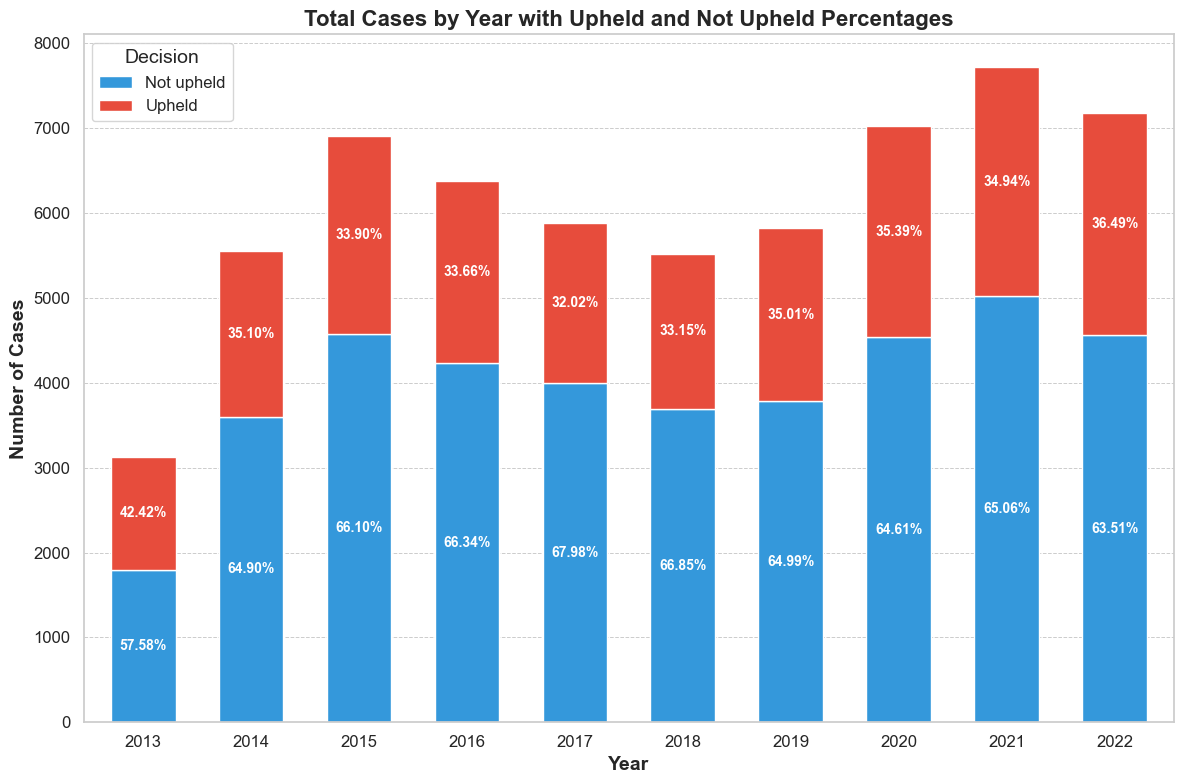

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns
data['date'] = pd.to_datetime(data['date'])

sns.set(style="whitegrid")

colors = ['#3498db', '#e74c3c']

yearly_data = data.groupby(data['date'].dt.to_period("Y"))['decision'].value_counts().unstack().fillna(0)
yearly_data['Total'] = yearly_data.sum(axis=1)
# Calculate Upheld percentage
yearly_data['Upheld Percent'] = (yearly_data['Upheld'] / yearly_data['Total'] * 100).round(2)

# Calculate  Not Upheld percentage
yearly_data['Not Upheld Percent'] = 100-yearly_data['Upheld Percent']


print(yearly_data)##for check

# Ensure the 'date' index is suitable for plotting by converting to datetime if not already done
yearly_data.index = pd.to_datetime(yearly_data.index.astype(str), format='%Y')



# Plot
fig, ax = plt.subplots(figsize=(12, 8))  # Larger figure size for clarity

# Use harmonious colors and increase bar width for better visibility
yearly_data[['Not upheld', 'Upheld']].plot(kind='bar', stacked=True, ax=ax, color=['#3498db', '#e74c3c'], width=0.6)

# Adding percentage labels with two decimal places and adjusting placement for clarity
for i, (index, row) in enumerate(yearly_data.iterrows()):
    ax.text(i, row['Not upheld']/2, f"{row['Not Upheld Percent']:.2f}%", ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(i, row['Not upheld'] + row['Upheld']/2, f"{row['Upheld Percent']:.2f}%", ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Setting title and labels with enhanced font settings
ax.set_title('Total Cases by Year with Upheld and Not Upheld Percentages', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Cases', fontsize=14, fontweight='bold')
plt.xticks(ticks=range(len(yearly_data)), labels=yearly_data.index.year, rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Enhancing grid lines and axis appearance
ax.yaxis.grid(True, linestyle='--', linewidth=0.7)  # Lighter and less prominent grid lines
ax.xaxis.grid(False)  # No vertical grid lines

# Enhance the legend
ax.legend(fontsize=12, title='Decision', title_fontsize='14', loc='upper left')

# Adjust layout to make room for labels
plt.tight_layout()



# Displaying the enhanced graph
plt.show()#for check


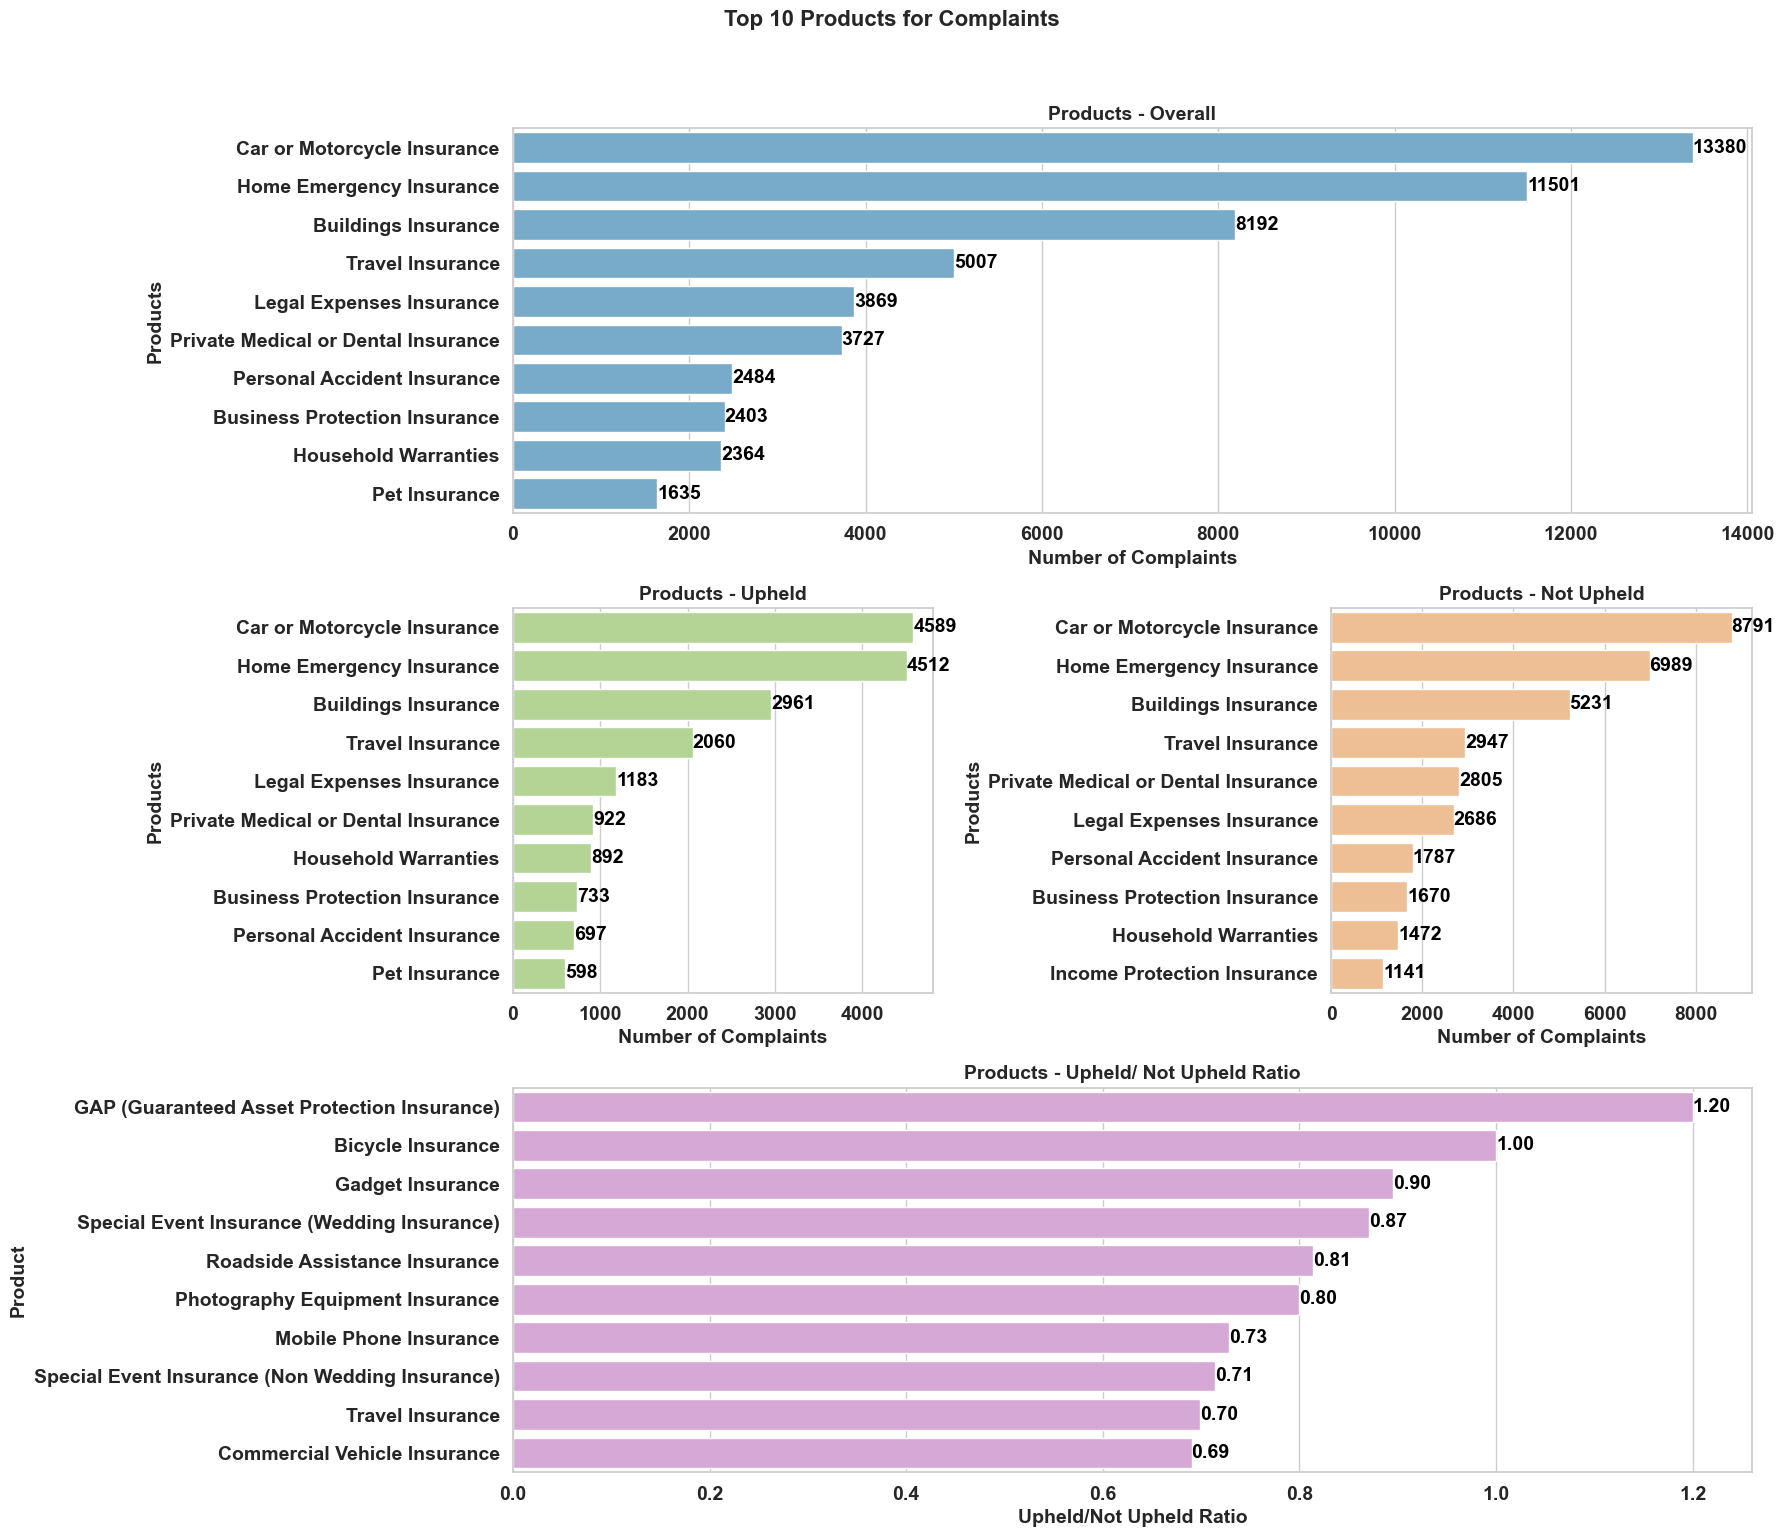

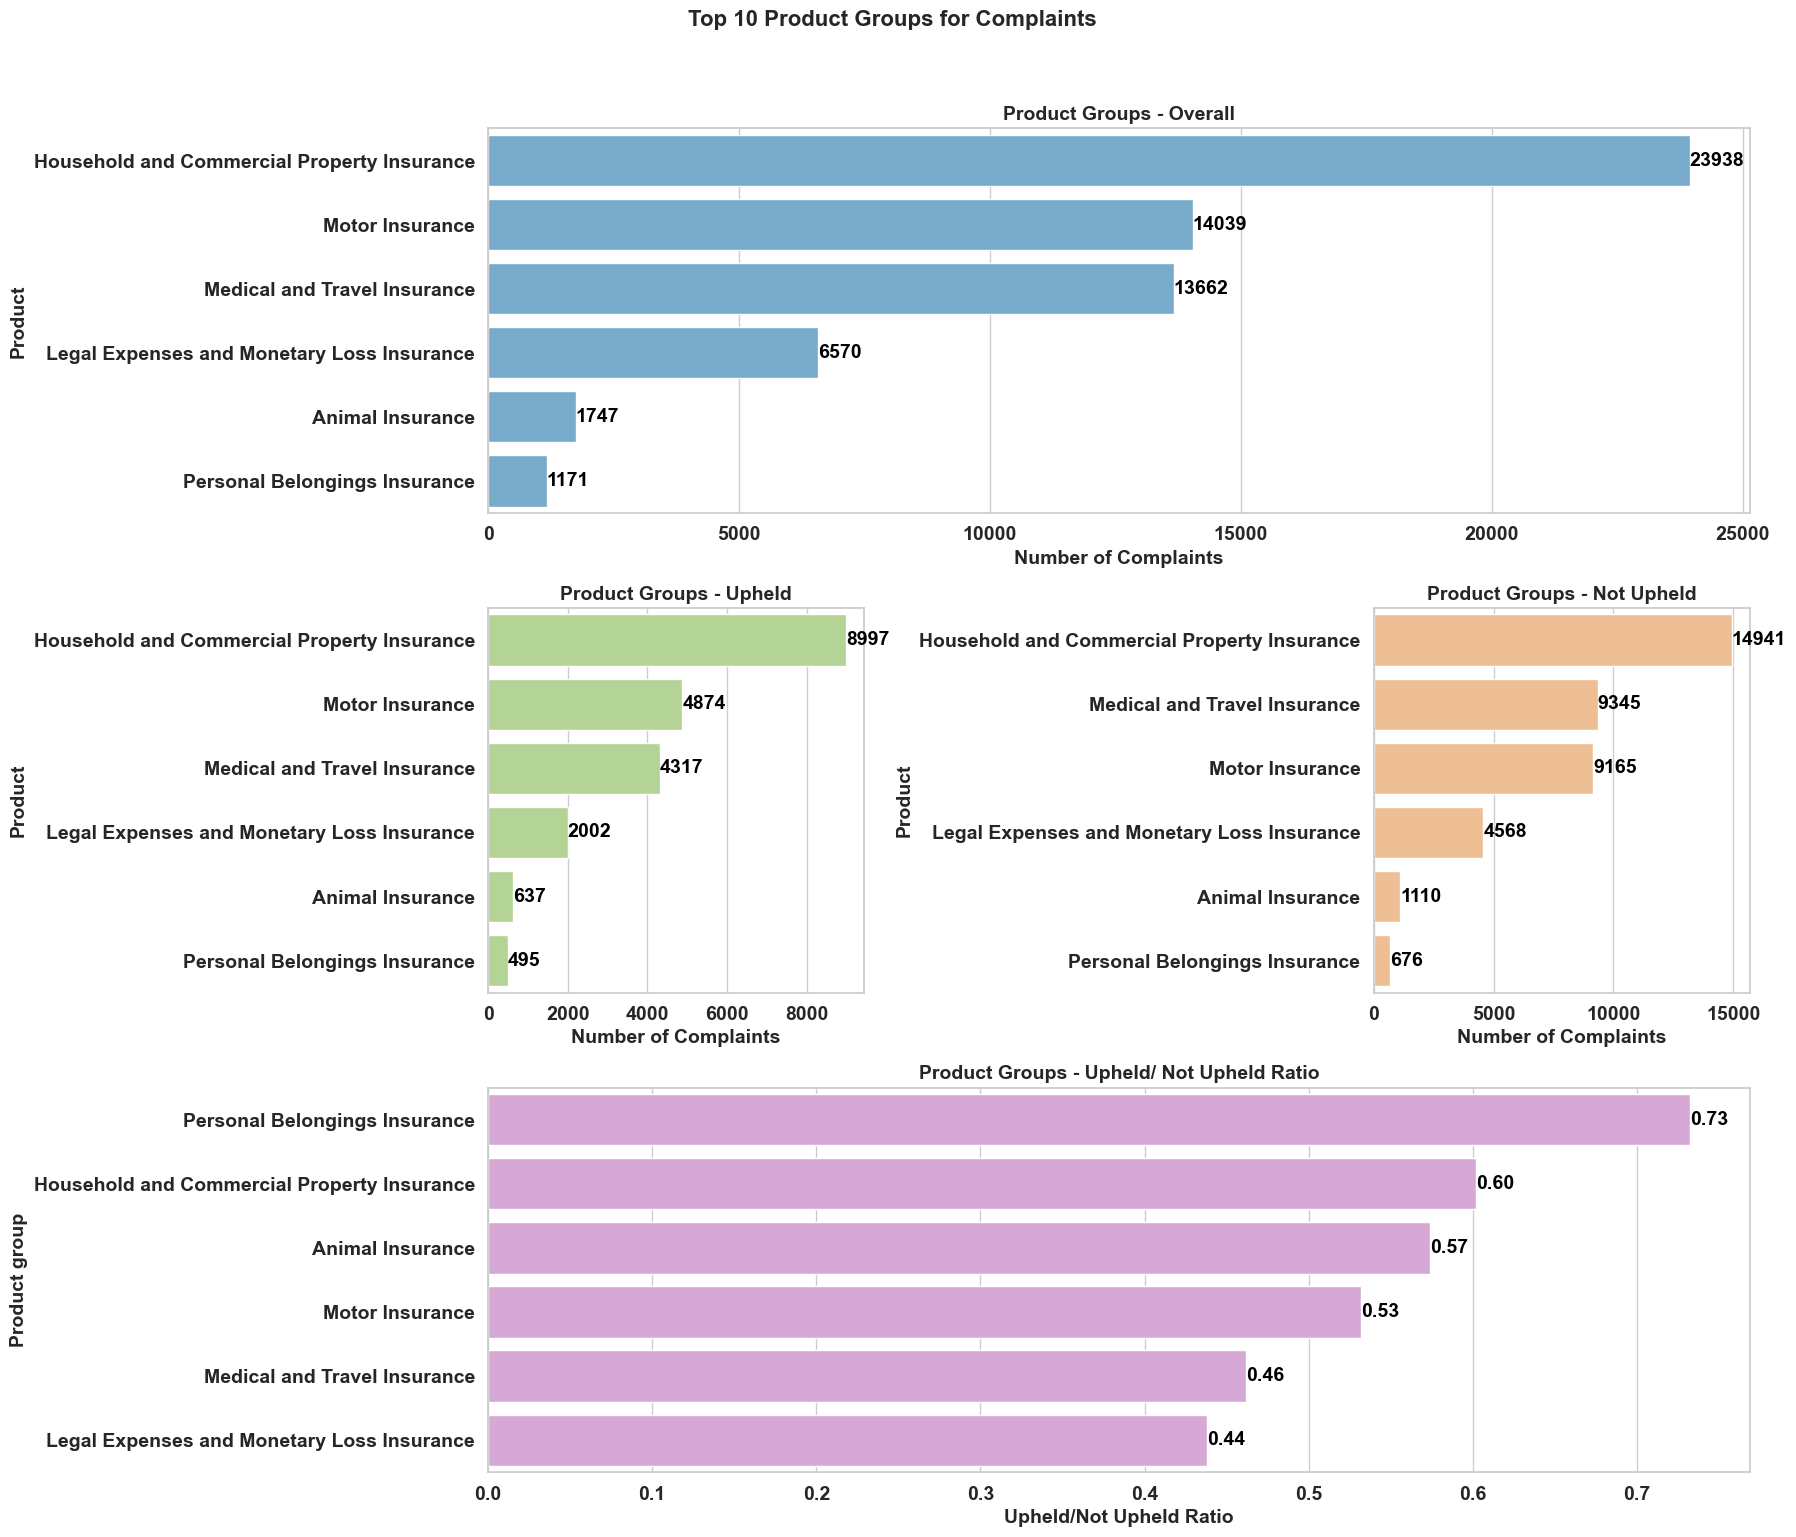

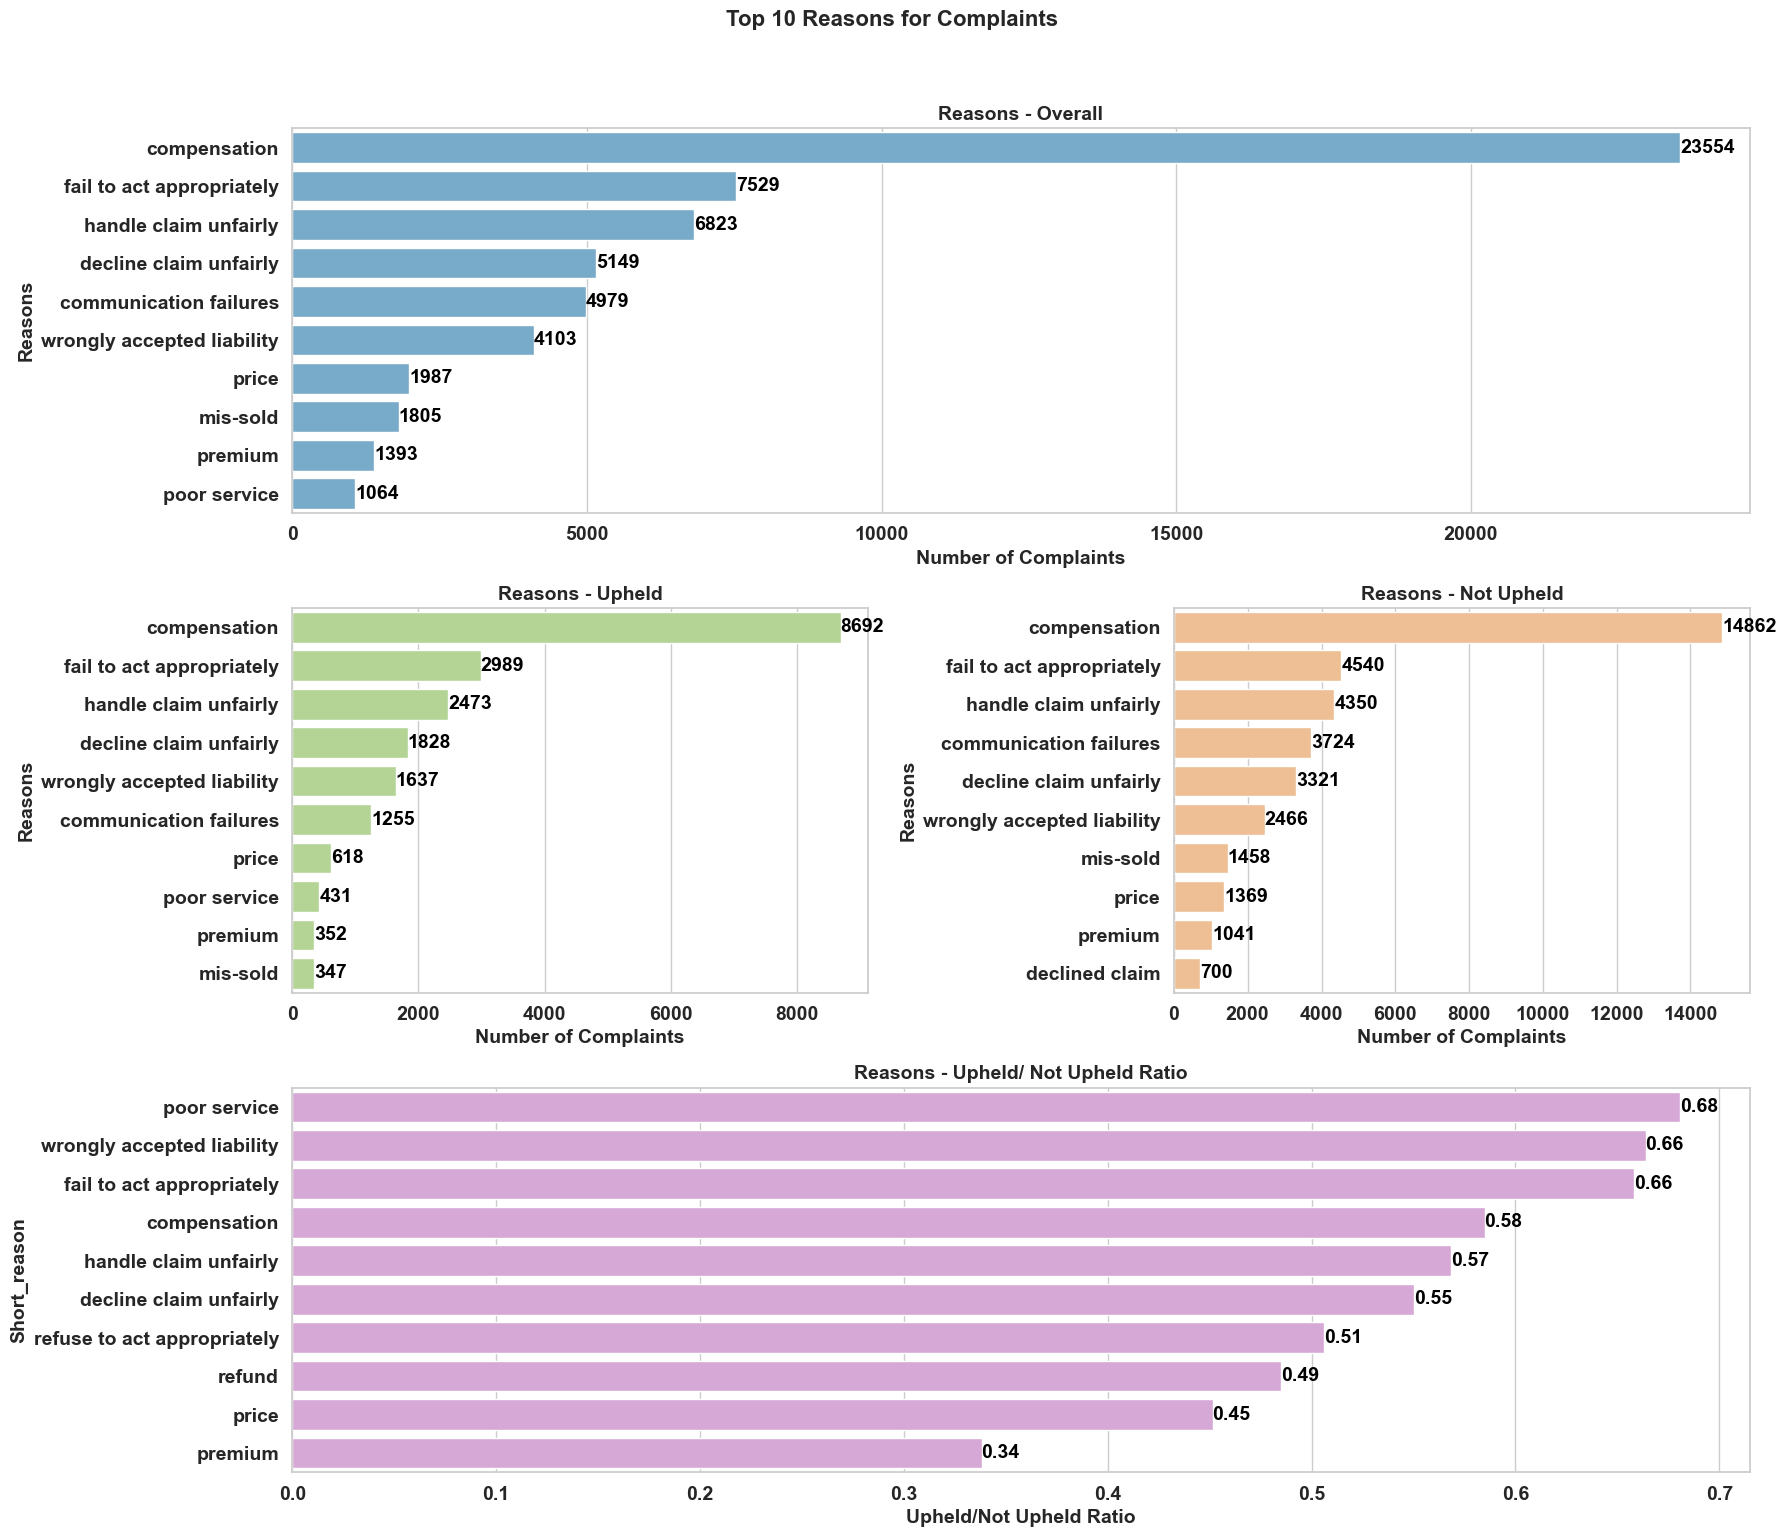

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure that the date column exists in timestamp format
data['date'] = pd.to_datetime(data['date'])

# Define a palette of colors
colors = ['#6BAED6', '#B2DF8A', '#FDBE85', '#DDA0DD']

# Define functions to draw each classification chart with adjusted text properties
def plot_top_10(data, attr, title, color, ax):
    sorted_data = data[attr].value_counts().nlargest(10)
    bar_plot = sns.barplot(y=sorted_data.index, x=sorted_data.values, color=color, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=14)  # Title bold and larger
    ax.set_xlabel('Number of Complaints', fontweight='bold', fontsize=14)  # X-label bold and larger
    ax.set_ylabel(title.split(' ')[0], fontweight='bold', fontsize=14)  # Y-label bold and larger
    # Setting bold font for ticks
    ax.tick_params(axis='x', labelsize=14)  # X-ticks larger
    ax.tick_params(axis='y', labelsize=14)  # Y-ticks larger
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    for i, v in enumerate(sorted_data.values):
        ax.text(v, i, f'{v}', color='black', va='center', fontweight='bold', fontsize=14)  # Text bold and larger

def plot_ratio_top_10(data, attr, title, color, ax):
    upheld_counts = data[data['decision'] == 'Upheld'][attr].value_counts()
    not_upheld_counts = data[data['decision'] == 'Not upheld'][attr].value_counts()
    ratio = upheld_counts / not_upheld_counts
    ratio = ratio.dropna().nlargest(10)
    sns.barplot(x=ratio.values, y=ratio.index, color=color, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=14)  # Title bold and larger
    ax.set_xlabel('Upheld/Not Upheld Ratio', fontweight='bold', fontsize=14)  # X-label bold and larger
    ax.set_ylabel(attr.capitalize(), fontweight='bold', fontsize=14)  # Y-label bold and larger
    # Setting bold font for ticks
    ax.tick_params(axis='x', labelsize=14)  # X-ticks larger
    ax.tick_params(axis='y', labelsize=14)  # Y-ticks larger
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    for i, v in enumerate(ratio.values):
        ax.text(v, i, f'{v:.2f}', color='black', va='center', fontweight='bold', fontsize=14)  # Text bold and larger
attributes = [
    ('product', 'Products'),
    ('product group', 'Product Groups'),
    ('short_reason', 'Reasons')
]
# Draw a classification chart for each attribute
for attr, title in attributes:
    fig = plt.figure(figsize=(18, 20))
    gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1])

    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])
    ax4 = fig.add_subplot(gs[2, :])

    fig.suptitle(f'Top 10 {title} for Complaints', fontsize=16, fontweight='bold')

    plot_top_10(data, attr, f'{title} - Overall', colors[0], ax1)
    plot_top_10(data[data['decision'] == 'Upheld'], attr, f'{title} - Upheld', colors[1], ax2)
    plot_top_10(data[data['decision'] == 'Not upheld'], attr, f'{title} - Not Upheld', colors[2], ax3)
    plot_ratio_top_10(data, attr, f'{title} - Upheld/ Not Upheld Ratio', colors[3], ax4)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


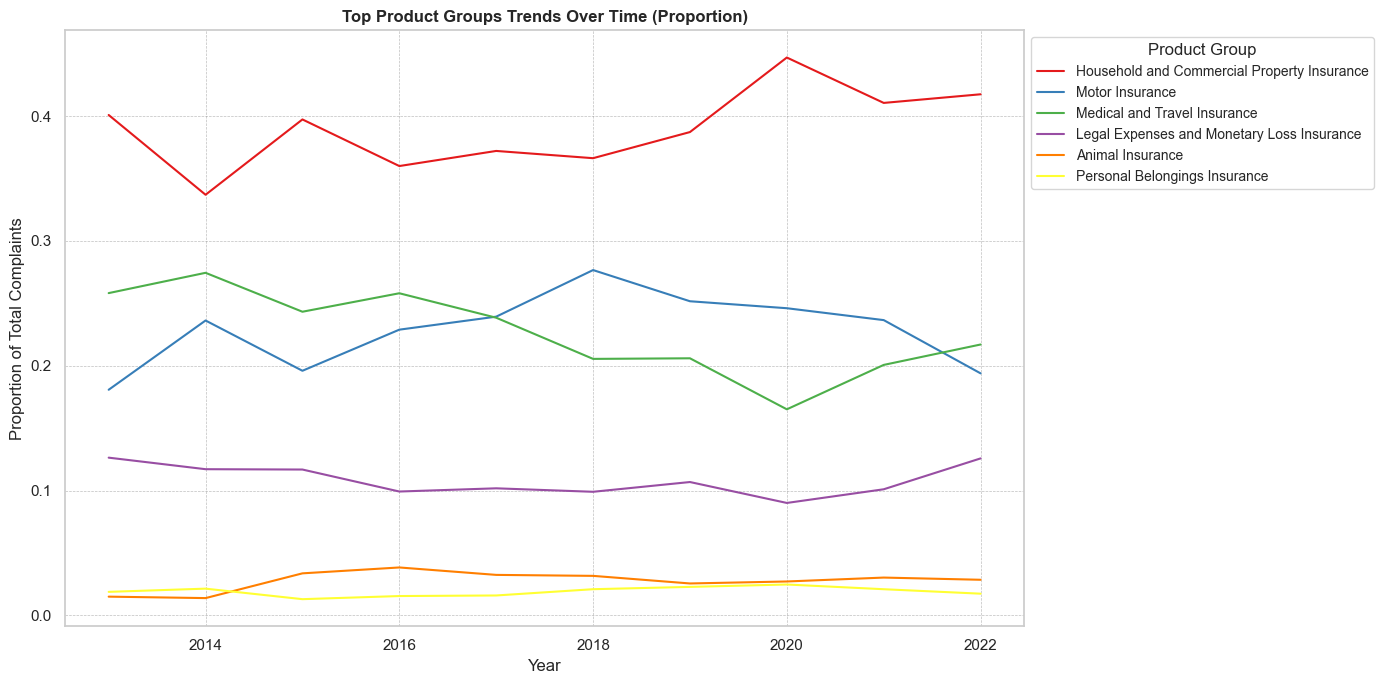

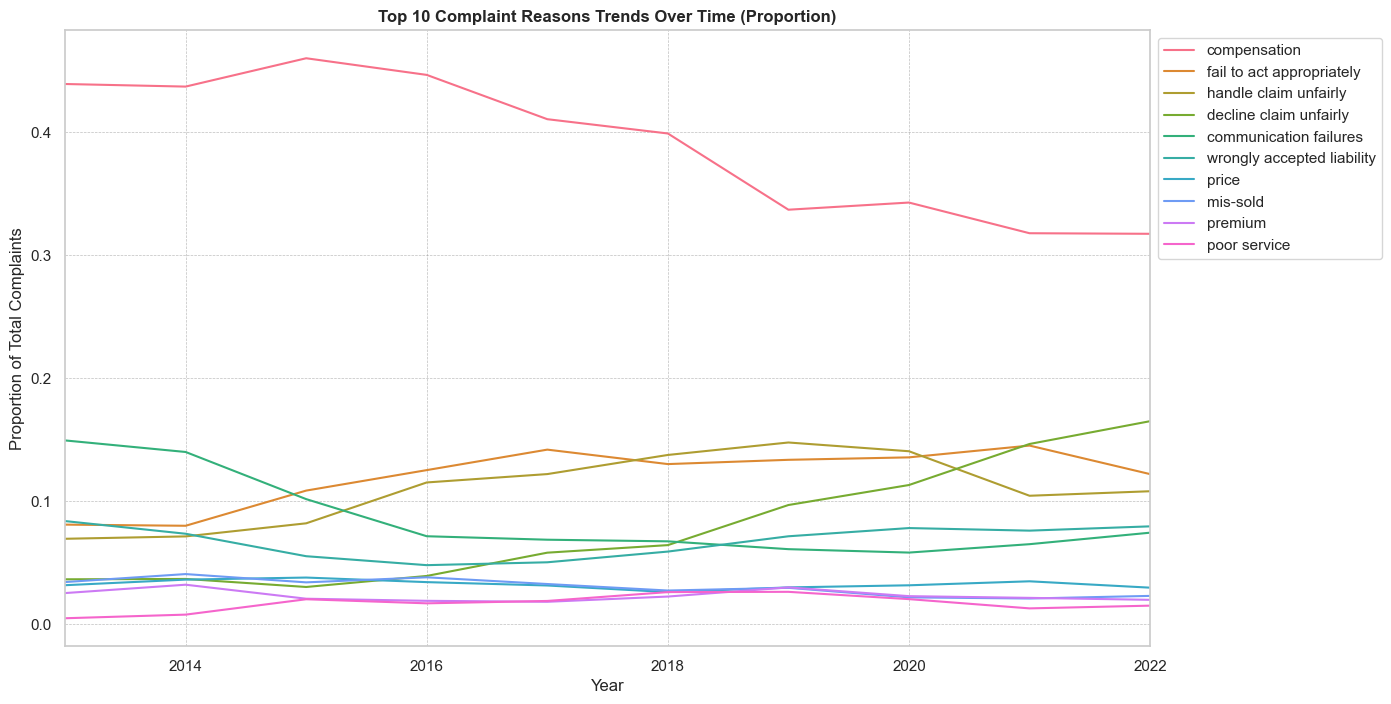

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the date column is in datetime format
data['date'] = pd.to_datetime(data['date'])

# Add a year column
data['year'] = data['date'].dt.year

# Select the top product groups
top_product_groups = data['product group'].value_counts().nlargest(10).index

# Filter data to keep only the top product groups
filtered_data = data[data['product group'].isin(top_product_groups)]

# Calculate the yearly counts for all product groups
yearly_counts = data.groupby(data['year']).size()

# Generate product group and year counts
product_group_year_counts = filtered_data.groupby(['year', 'product group']).size().unstack(fill_value=0)

# Calculate the proportions
product_group_year_proportions = product_group_year_counts.div(yearly_counts, axis=0)

# Set Seaborn style
sns.set(style="whitegrid")

# Plot line chart for each product group with a high contrast color palette
plt.figure(figsize=(14, 7))
palette = sns.color_palette("Set1", len(top_product_groups))

for i, product_group in enumerate(top_product_groups):
    plt.plot(product_group_year_proportions.index, product_group_year_proportions[product_group], label=product_group,
             color=palette[i])

plt.title('Top Product Groups Trends Over Time (Proportion)',fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Proportion of Total Complaints')
plt.xticks(rotation=0)  # Ensure x-axis labels are horizontal
plt.legend(title='Product Group', bbox_to_anchor=(1, 1), loc='upper left', fontsize='small')

# Customize grid lines
plt.grid(True, linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the date column is in datetime format
data['date'] = pd.to_datetime(data['date'])

# Set the Seaborn style
sns.set(style="whitegrid")

# Select the top 10 complaint reasons
top_reasons = data['short_reason'].value_counts().nlargest(10).index

# Define distinct colors for each reason
colors = sns.color_palette("husl", len(top_reasons))

# Plot the trend for each complaint reason over time
plt.figure(figsize=(14, 8))

# Calculate the yearly counts for all reasons
yearly_counts = data.groupby(data['date'].dt.to_period("Y")).size()

for i, reason in enumerate(top_reasons):
    reason_data = data[data['short_reason'] == reason]
    yearly_reason_counts = reason_data.groupby(reason_data['date'].dt.to_period("Y")).size()
    yearly_proportion = yearly_reason_counts / yearly_counts
    yearly_proportion.plot(kind='line', label=reason, color=colors[i])

plt.title('Top 10 Complaint Reasons Trends Over Time (Proportion)',fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Proportion of Total Complaints')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Customize grid lines
plt.grid(True, linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

plt.show()

Word Cloud 

In [198]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
#clean text first
# Merge  text fields
data['all_text'] =  data['the complaint'] + ' '+ data['what happened']

# clean text
def clean_text(text):
    
    text = re.sub(r'\d+', '', text)  # Remove numbers 
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove  punctuation
    text = text.lower()  # Convert to lowercase
    return text

data['cleaned_text'] = data['all_text'].apply(clean_text)

# set stopwords
stop_words = set(stopwords.words('english'))
data['tokenized_text'] = data['cleaned_text'].apply(lambda x: [word for word in word_tokenize(x) if word not in stop_words])

# print for check
data[['cleaned_text', 'tokenized_text']].head()



,cleaned_text,tokenized_text
0,miss s complains that hsbc bank plc sold her l...,"[miss, complains, hsbc, bank, plc, sold, lifec..."
1,mr h’s is unhappy that royal sun alliance ins...,"[mr, h, ’, unhappy, royal, sun, alliance, insu..."
2,mr w has complained about amtrust europe limit...,"[mr, w, complained, amtrust, europe, limited, ..."
3,mr and mrs s complain that allianz insurance p...,"[mr, mrs, complain, allianz, insurance, plc, r..."
4,ms b has complained about how alternative acco...,"[ms, b, complained, alternative, accommodation..."


In [199]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Remove company abbreviations and titles
custom_stop_words = ENGLISH_STOP_WORDS.union({'mr', 'mrs', 'ms', 'miss', 'it', 'was', 'in', 'his', 'he', 'her', 'she', 'they', 'aa', 'ad', 'afh', 'ag', 'aig', 'arag', 'atlanta', 'awp', 'axa', 'axis', 'bcr', 'bhsf', 'big', 'bisl', 'bupa', 'cigna', 'cna', 'dac', 'das', 'doa', 'ergo', 'etu', 'eui', 'fisc', 'gi', 'group', 'hcc', 'hdi', 'hmca', 'home', 'hsb', 'hsbc', 'iard', 'insurance', 'insure', 'jsc', 'kgm', 'limited', 'llp', 'mce', 'md', 'nv', 'ovo', 'pcc', 'plc', 'pm', 'ppp', 'qbe', 'qic', 'rac', 'sa', 'se', 'services', 'sga', 'tbo', 'ticorp', 'uia', 'uk', 'unum', 'usaa', 'wdp', 'xl', 'rsa', 'aviva', 'ageas', 'uki', 'insurer', 'didn','lv'})

# Convert set to list to meet the parameter requirements
custom_stop_words_list = list(custom_stop_words)

# Configuring the TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=2000, max_df=0.95, min_df=2, stop_words=custom_stop_words_list)
tfidf_matrix = vectorizer.fit_transform(data['cleaned_text'])

# Getting the names of TF-IDF features
tfidf_feature_names = vectorizer.get_feature_names_out()

# Getting the TF-IDF values for each document
tfidf_scores = tfidf_matrix.toarray()

# Extracting the most important keywords for each document
important_words = []
for doc in tfidf_scores:
    # Sorting the indices of the terms in descending order by their TF-IDF score and selecting the top 10
    top_words = [tfidf_feature_names[i] for i in doc.argsort()[:-10 - 1:-1]]
    important_words.append(top_words)

# Storing the important words in the dataframe
data['important_words'] = important_words

# check
print(data[['important_words']].head())


                                     important_words
0  [policies, unsuitable, critical, adviser, prem...
1  [car, solicitor, getting, park, driver, repair...
2  [phone, amtrust, mobile, believed, isn, mechan...
3  [allianz, vet, pet, void, mention, policy, bou...
4  [andrew, st, properties, bedroom, agent, flat,...


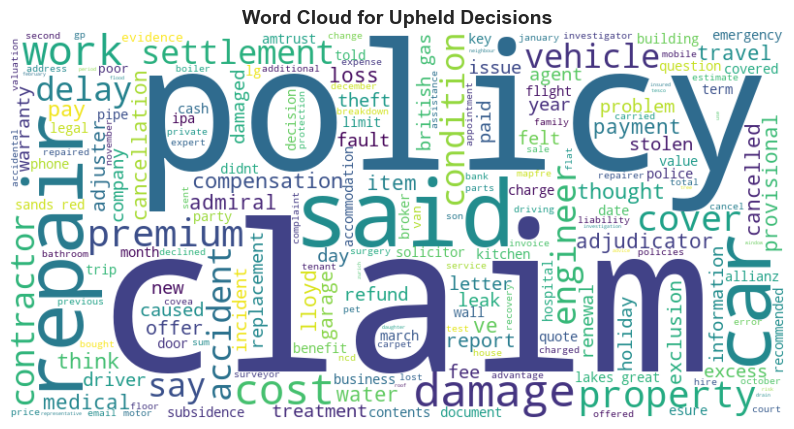

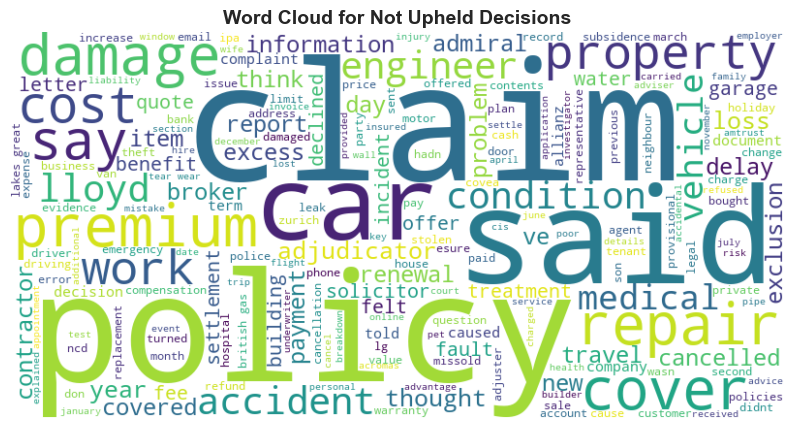

In [200]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# generate wordcloud
def generate_wordcloud(words_list, title):
    # check whether words_list is null or empty
    if not words_list:
        print(f"No words to display for '{title}'.")
        return
    # merge list
    all_words = [word for sublist in words_list for word in sublist]
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))
    # plot
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# Filter data for 'up held' and 'not up held'
upheld_data = data[data['decision'] == 'Upheld']['important_words'].tolist()
not_upheld_data = data[data['decision'] == 'Not upheld']['important_words'].tolist()

# Generate 'upheld' word cloud
generate_wordcloud(upheld_data, 'Word Cloud for Upheld Decisions')

# Generate 'not upheld' word cloud
generate_wordcloud(not_upheld_data, 'Word Cloud for Not Upheld Decisions')


TF-IDF

In [201]:

print(data['decision'].value_counts())

decision
Not upheld    39805
Upheld        21322
Name: count, dtype: int64


In [202]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

data = data.dropna(subset=['what happened', 'the complaint', 'decision'])

# Merge text columns and convert decision columns into binary labels
data['combined_text'] = data['what happened'] + ' ' + data['the complaint']
data['decision'] = data['decision'].apply(lambda x: 1 if x == 'Upheld' else 0)


In [203]:
print(data['decision'].value_counts())

decision
0    39805
1    21322
Name: count, dtype: int64


In [204]:

import re
import string
import nltk
from nltk.corpus import stopwords
#clean text
#nltk.download('stopwords')
data['combined_text'] = data['what happened'] + ' ' + data['the complaint']
data['combined_text'] = data['combined_text'].apply(lambda x: x.lower())  # lowcase
data['combined_text'] = data['combined_text'].apply(lambda x: re.sub(r'\d+', '', x))  # remove number
data['combined_text'] = data['combined_text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))  # remove string #punctuation
# customize stopwords
custom_stopwords = set(stopwords.words('english'))


additional_stopwords = {'mr', 'mrs', 'ms', 'miss', 'it', 'was', 'in', 'his', 'he', 'her', 'she', 'they', 'aa', 'ad', 'afh', 'ag', 'aig', 'arag', 'atlanta', 'awp', 'axa', 'axis', 'bcr', 'bhsf', 'big', 'bisl', 'bupa', 'cigna', 'cna', 'dac', 'das', 'doa', 'ergo', 'etu', 'eui', 'fisc', 'gi', 'group', 'hcc', 'hdi', 'hmca', 'home', 'hsb', 'hsbc', 'iard', 'insurance', 'insure', 'jsc', 'kgm', 'limited', 'llp', 'mce', 'md', 'nv', 'ovo', 'pcc', 'plc', 'pm', 'ppp', 'qbe', 'qic', 'rac', 'sa', 'se', 'services', 'sga', 'tbo', 'ticorp', 'uia', 'uk', 'unum', 'usaa', 'wdp', 'xl', 'rsa', 'aviva', 'ageas', 'uki', 'insurer', 'didn','lv'}
custom_stopwords.update(additional_stopwords)
# remove stopwords
def clean_text_with_stopwords(text):
    tokens = [word for word in text.split() if word not in custom_stopwords]
    return ' '.join(tokens)

data['cleaned_text'] = data['combined_text'].apply(clean_text_with_stopwords)




In [ ]:
!pip install --upgrade xgboost


LogisticRegression best parameters: {'C': 10}
LogisticRegression best score: 0.7866
LogisticRegression Test Accuracy: 0.7909
LogisticRegression Confusion Matrix:
 [[6931  997]
 [1560 2738]]
LogisticRegression Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84      7928
           1       0.73      0.64      0.68      4298

    accuracy                           0.79     12226
   macro avg       0.77      0.76      0.76     12226
weighted avg       0.79      0.79      0.79     12226



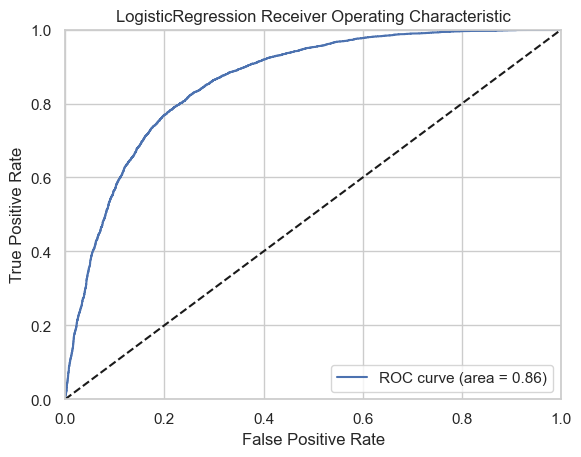

RandomForestClassifier best parameters: {'n_estimators': 200}
RandomForestClassifier best score: 0.7883
RandomForestClassifier Test Accuracy: 0.7850
RandomForestClassifier Confusion Matrix:
 [[7207  721]
 [1908 2390]]
RandomForestClassifier Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.91      0.85      7928
           1       0.77      0.56      0.65      4298

    accuracy                           0.78     12226
   macro avg       0.78      0.73      0.75     12226
weighted avg       0.78      0.78      0.78     12226



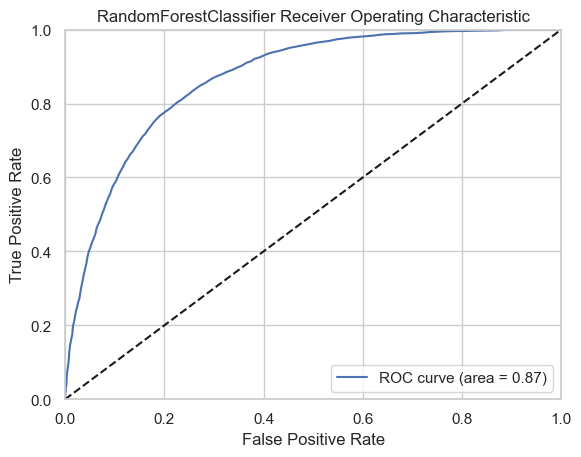

XGBClassifier best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
XGBClassifier best score: 0.8175
XGBClassifier Test Accuracy: 0.8180
XGBClassifier Confusion Matrix:
 [[6983  945]
 [1280 3018]]
XGBClassifier Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      7928
           1       0.76      0.70      0.73      4298

    accuracy                           0.82     12226
   macro avg       0.80      0.79      0.80     12226
weighted avg       0.82      0.82      0.82     12226



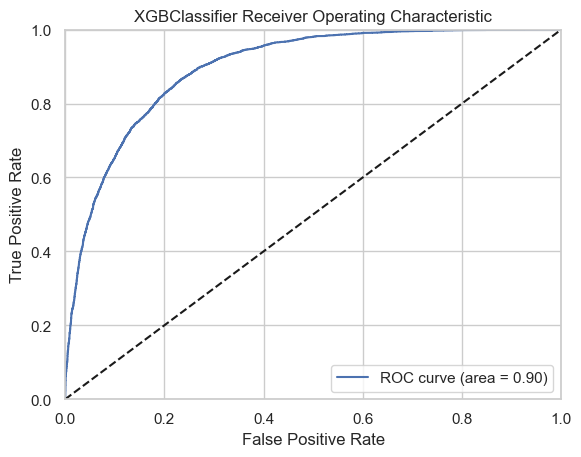

In [205]:
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import xgboost as xgb
from xgboost import XGBClassifier

# TF-IDF
vectorizer = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.95)
X = vectorizer.fit_transform(data['cleaned_text'])
y = data['decision']

#Divide the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set model and parameter dictionary to find optimal parameter
models_params = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.1, 1, 10]
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100, 200]
        }
    },
    'XGBClassifier': {
        'model': XGBClassifier(eval_metric='logloss'),
        'params': {
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1]
        }
    }
}

# Model selection and parameter optimization through cross validation and grid search
for model_name, mp in models_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy')
    clf.fit(X_train, y_train)
    print(f"{model_name} best parameters: {clf.best_params_}")
    print(f"{model_name} best score: {clf.best_score_:.4f}")

    y_pred = clf.predict(X_test)
    print(f"{model_name} Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"{model_name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"{model_name} Classification Report:\n", classification_report(y_test, y_pred))

    # Draw ROC curve
    if hasattr(clf.best_estimator_, "predict_proba"):
        y_bin = label_binarize(y_test, classes=[0, 1])
        fpr, tpr, _ = roc_curve(y_bin, clf.best_estimator_.predict_proba(X_test)[:,1])
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.0])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name} Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()


In [206]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier



# The optimal parameters obtained from the previous step
optimal_params = {
    'LogisticRegression': {'C': 10},
    'RandomForestClassifier': {'n_estimators': 200},
    'XGBClassifier': {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
}

# initialize model
models = {
    'LogisticRegression': LogisticRegression(C=optimal_params['LogisticRegression']['C']),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=optimal_params['RandomForestClassifier']['n_estimators']),
    'XGBClassifier': XGBClassifier(learning_rate=optimal_params['XGBClassifier']['learning_rate'],
                                   max_depth=optimal_params['XGBClassifier']['max_depth'],
                                   n_estimators=optimal_params['XGBClassifier']['n_estimators'],
                                   eval_metric='logloss')
}

# Set up cross validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# run cross validation
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    print(f"{model_name} Cross-Validation Scores: {cv_scores}")
    print(f"{model_name} Mean CV Accuracy: {np.mean(cv_scores):.4f}")
    print(f"{model_name} Standard Deviation in CV: {np.std(cv_scores):.4f}\n")


LogisticRegression Cross-Validation Scores: [0.79085555 0.78954687 0.79190184 0.79149284 0.78838446]
LogisticRegression Mean CV Accuracy: 0.7904
LogisticRegression Standard Deviation in CV: 0.0013

RandomForestClassifier Cross-Validation Scores: [0.78766563 0.78463929 0.79525562 0.79533742 0.79075665]
RandomForestClassifier Mean CV Accuracy: 0.7907
RandomForestClassifier Standard Deviation in CV: 0.0042

XGBClassifier Cross-Validation Scores: [0.81743825 0.81923769 0.8198773  0.82380368 0.82249489]
XGBClassifier Mean CV Accuracy: 0.8206
XGBClassifier Standard Deviation in CV: 0.0023



| **Model**                    | **LogisticRegression** | **RandomForestClassifier** | **XGBClassifier** |
|------------------------------|------------------------|----------------------------|-------------------|
| **Accuracy**                 | 0.79                   | 0.78                       | 0.82              |
| **Macro Avg Precision**      | 0.77                   | 0.78                       | 0.80              |
| **Macro Avg Recall**         | 0.76                   | 0.73                       | 0.79              |
| **Macro Avg F1-Score**       | 0.76                   | 0.75                       | 0.80              |
| **Precision Class 0**        | 0.87                   | 0.91                       | 0.88              |
| **Precision Class 1**        | 0.64                   | 0.56                       | 0.70              |
| **Mean CV Accuracy**         | 0.7904                 | 0.7907                     | 0.8206            |
| **Standard Deviation in CV** | 0.0013                 | 0.0042                     | 0.0023             |


In [ ]:
!pip install shap

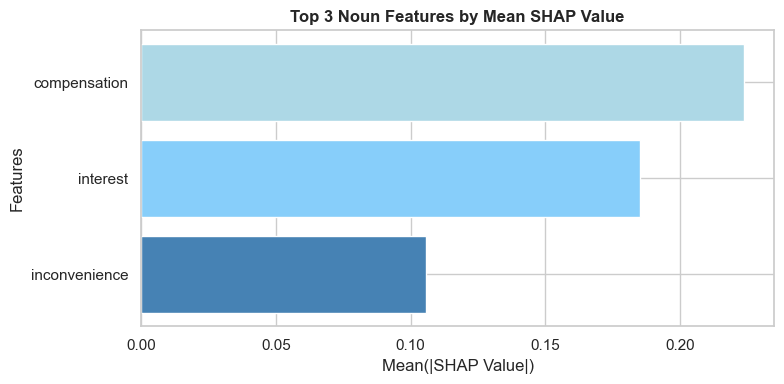

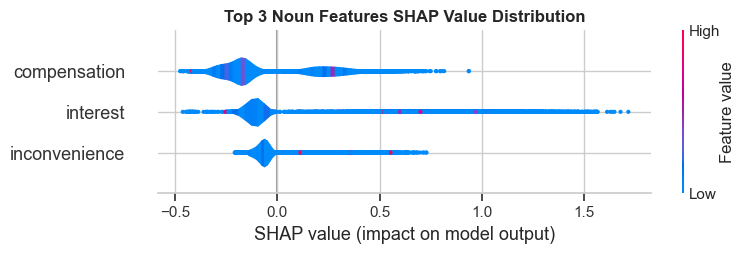

In [207]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import shap

#fit model
opt_xgb_model = XGBClassifier(learning_rate=0.1, max_depth=7, n_estimators=200, eval_metric='logloss')
opt_xgb_model.fit(X, y)

nlp = spacy.load("en_core_web_sm")

# Obtain TF-IDF vectorized feature names
feature_names = vectorizer.get_feature_names_out()

#  filter out noun features
noun_features = [feature for feature in feature_names if nlp(feature)[0].pos_ == 'NOUN']

# Search for the index of noun features
noun_indices = [i for i, feature in enumerate(feature_names) if feature in noun_features]

# Initialize SHAP interpreter and calculate SHAP value
explainer = shap.TreeExplainer(opt_xgb_model)
shap_values = explainer.shap_values(X)

# Filter out the SHAP values of these noun features
noun_shap_values = shap_values[:, noun_indices]
noun_feature_names = np.array(feature_names)[noun_indices]

# Sort SHAP values and select the top three
sorted_noun_indices = np.argsort(-np.abs(noun_shap_values).mean(0))[:3]
top_noun_shap_values = noun_shap_values[:, sorted_noun_indices]
top_noun_feature_names = noun_feature_names[sorted_noun_indices]

# plot noun features by mean shap value
plt.figure(figsize=(8, 4))
#colors = ['#c0c0c0', '#c0c0c0', '#c0c0c0']  # refine color
colors = ['#add8e6', '#87cefa', '#4682b4']# refine color
plt.barh(top_noun_feature_names, np.abs(top_noun_shap_values).mean(0), color=colors)
plt.xlabel('Mean(|SHAP Value|)')
plt.ylabel('Features')
plt.title('Top 3 Noun Features by Mean SHAP Value', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# plot shap violin

dense_X_subset = X[:, sorted_noun_indices].toarray()  
plt.figure(figsize=(8, 4))
shap.summary_plot(top_noun_shap_values, dense_X_subset, feature_names=top_noun_feature_names, plot_type='violin',show=False)
plt.title('Top 3 Noun Features SHAP Value Distribution', fontweight='bold')
plt.tight_layout()
plt.show()
